# Data Setting

### Libraries

In [170]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd 
import os
import glob
import matplotlib.font_manager as fm
import platform

# 1. 시스템 정보 확인
system_name = platform.system()

if system_name == 'Windows':
    # Windows 환경: 'Malgun Gothic'(맑은 고딕) 권장
    font_name = 'Malgun Gothic'
elif system_name == 'Darwin':
    # macOS 환경: 'AppleGothic' 권장
    font_name = 'AppleGothic'
else:
    # Linux 또는 기타 환경 (NanumGothic 설치 가정)
    # 나눔고딕이 없을 경우 'DejaVu Sans' 등 다른 폰트로 대체될 수 있음
    font_name = 'NanumGothic'

# 2. Matplotlib 전역 폰트 설정
plt.rcParams['font.family'] = font_name
# 3. 마이너스 부호 깨짐 방지 설정 (옵션)
# Matplotlib은 기본적으로 마이너스 부호를 유니코드가 아닌 문자로 처리하여 깨질 수 있습니다.
plt.rcParams['axes.unicode_minus'] = False

print(f"현재 시스템: {system_name}")
print(f"Matplotlib 폰트 설정 완료: '{font_name}'")

# (참고: 만약 폰트 설정 후에도 깨진다면, 폰트가 시스템에 설치되어 있는지, 
# 혹은 matplotlib의 폰트 캐시를 삭제해야 할 수도 있습니다.)

현재 시스템: Darwin
Matplotlib 폰트 설정 완료: 'AppleGothic'


### Load data

In [229]:
import pandas as pd
import glob
import os

# 데이터 파일이 저장된 폴더 경로
path = './Data'

# CSV 파일 검색
all_file_list = glob.glob(os.path.join(path, '20*.csv'))
exclude_file_list = ['./Data/2025.csv', './Data/2025_hs.csv']
file_list = [f for f in all_file_list if f not in exclude_file_list]

print(f"찾은 CSV 파일 개수: {len(file_list)}")
print(f"파일 목록: {file_list}")

all_data_frames = []

for file in file_list:
    try:
        df_single_year = pd.read_csv(file, encoding='utf-8', low_memory=False)
        all_data_frames.append(df_single_year)
    except UnicodeDecodeError:
        try:
            df_single_year = pd.read_csv(file, encoding='cp949', low_memory=False)
            all_data_frames.append(df_single_year)
        except Exception as e:
            print(f"  [실패] '{os.path.basename(file)}' 파일은 두 인코딩 모두 실패: {e}")

# 파일이 성공적으로 하나라도 읽혔다면 데이터 통합을 진행
if all_data_frames:
    df_combined = pd.concat(all_data_frames, ignore_index=True)
    print(f"\n통합된 데이터프레임 크기: {df_combined.shape}")
    
else:
    print("\n통합할 데이터가 없습니다. 파일 경로 또는 파일 내용을 확인해주세요.")

df = df_combined.copy()

찾은 CSV 파일 개수: 7
파일 목록: ['./Data/2020.csv', './Data/2021.csv', './Data/2023.csv', './Data/2022.csv', './Data/2019.csv', './Data/2018.csv', './Data/2024.csv']

통합된 데이터프레임 크기: (3557756, 23)


### Data Structure

In [230]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3557756 entries, 0 to 3557755
Data columns (total 23 columns):
 #   Column   Dtype  
---  ------   -----  
 0   접수년도     int64  
 1   자치구코드    int64  
 2   자치구명     object 
 3   법정동코드    int64  
 4   법정동명     object 
 5   지번구분코드   float64
 6   지번구분     object 
 7   본번       float64
 8   부번       float64
 9   층        float64
 10  계약일      int64  
 11  전월세구분    object 
 12  임대면적     float64
 13  보증금(만원)  int64  
 14  임대료(만원)  int64  
 15  건물명      object 
 16  건축년도     float64
 17  건물용도     object 
 18  계약기간     object 
 19  신규계약구분   object 
 20  갱신청구권사용  object 
 21  종전보증금    float64
 22  종전임대료    float64
dtypes: float64(8), int64(6), object(9)
memory usage: 624.3+ MB


In [231]:
print(np.sort(df['접수년도'].unique()))

[2018 2019 2020 2021 2022 2023 2024]


In [232]:
print("--- DataFrame의 실제 컬럼명 ---")
print(df.columns)

--- DataFrame의 실제 컬럼명 ---
Index(['접수년도', '자치구코드', '자치구명', '법정동코드', '법정동명', '지번구분코드', '지번구분', '본번', '부번',
       '층', '계약일', '전월세구분', '임대면적', '보증금(만원)', '임대료(만원)', '건물명', '건축년도',
       '건물용도', '계약기간', '신규계약구분', '갱신청구권사용', '종전보증금', '종전임대료'],
      dtype='object')


In [233]:
print(df.head(5))

   접수년도  자치구코드 자치구명  법정동코드   법정동명  지번구분코드 지번구분      본번    부번     층  ...  \
0  2020  11170  용산구  11300  원효로2가     1.0   대지     1.0   0.0   6.0  ...   
1  2020  11440  마포구  11000   노고산동     1.0   대지     1.0   1.0   9.0  ...   
2  2020  11440  마포구  11000   노고산동     1.0   대지     1.0   1.0  10.0  ...   
3  2020  11590  동작구  10700    사당동     1.0   대지  1007.0  19.0   7.0  ...   
4  2020  11590  동작구  10700    사당동     1.0   대지  1007.0  19.0   3.0  ...   

   보증금(만원) 임대료(만원)            건물명    건축년도  건물용도 계약기간  신규계약구분 갱신청구권사용 종전보증금  \
0     5000       0        \t(1)\t  1990.0  오피스텔  NaN     NaN     NaN   NaN   
1    18500       0      \t(1-1)\t  1998.0  오피스텔  NaN     NaN     NaN   NaN   
2    22000       0      \t(1-1)\t  1998.0  오피스텔  NaN     NaN     NaN   NaN   
3      500      24  \t(1007-19)\t  2002.0  오피스텔  NaN     NaN     NaN   NaN   
4    17325       0  \t(1007-19)\t  2002.0  오피스텔  NaN     NaN     NaN   NaN   

  종전임대료  
0   NaN  
1   NaN  
2   NaN  
3   NaN  
4   NaN  

[5 rows x 23 column

## Data Cleaning & Preparation

In [234]:
# 필요한 데이터 선택
selected_columns = ['접수년도', '자치구명', '법정동명', '전월세구분', '임대면적', '보증금(만원)', '임대료(만원)', '건물용도', '건축년도']
df = df[selected_columns]
print(df.tail(3))

         접수년도  자치구명  법정동명 전월세구분   임대면적  보증금(만원)  임대료(만원)   건물용도    건축년도
3557753  2024  동대문구   신설동    월세  34.05     5000      130  연립다세대  2023.0
3557754  2024   성북구  하월곡동    전세  73.77    25000        0  단독다가구     NaN
3557755  2024   강서구  내발산동    월세  66.59    20000       90  단독다가구     NaN


In [235]:
# 법정동명 확인
#print(df['법정동명'].unique())

# 원하는 동이 있는지 확인
target_dong = '합정동'
if target_dong in df['법정동명'].values:
    print(f"'{target_dong}' 동이 데이터에 존재합니다.")
else:
    print(f"'{target_dong}' 동이 데이터에 존재하지 않습니다.")

'합정동' 동이 데이터에 존재합니다.


In [236]:
# 결측치 및 이상치 처리
print(df.isnull().sum())
df = df.dropna()
df = df[df['임대면적'] > 0]

접수년도           0
자치구명           0
법정동명           0
전월세구분          9
임대면적           0
보증금(만원)        0
임대료(만원)        0
건물용도           0
건축년도       91941
dtype: int64


### 임대면적 분포

Text(0.5, 1.0, '임대면적 분포')

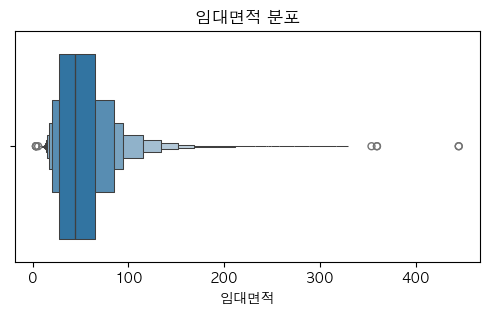

In [237]:
plt.figure(figsize=(6, 3))
sns.boxenplot(x=df['임대면적'])
plt.title('임대면적 분포')

Text(0.5, 1.0, '임대면적 분포 (이상치 제거 후)')

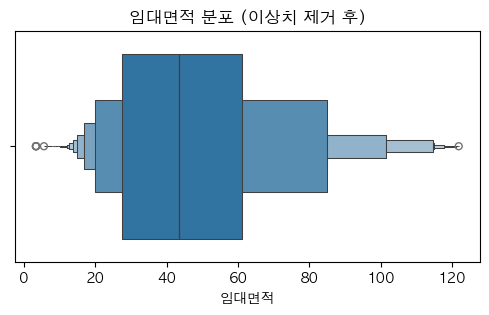

In [238]:
# 이상치 제거
q1 = df['임대면적'].quantile(0.25)
q3 = df['임대면적'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr ; upper_bound = q3 + 1.5 * iqr
df = df[(df['임대면적'] >= lower_bound) & (df['임대면적'] <= upper_bound)]

plt.figure(figsize=(6, 3))
sns.boxenplot(x=df['임대면적'])
plt.title('임대면적 분포 (이상치 제거 후)')

### 입대료 분포


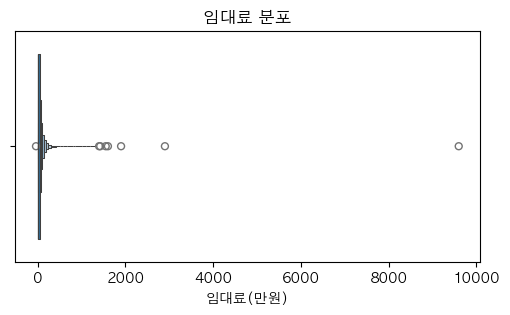

In [239]:
plt.figure(figsize=(6, 3))
sns.boxenplot(x=df['임대료(만원)'])
plt.title('임대료 분포')
plt.show()

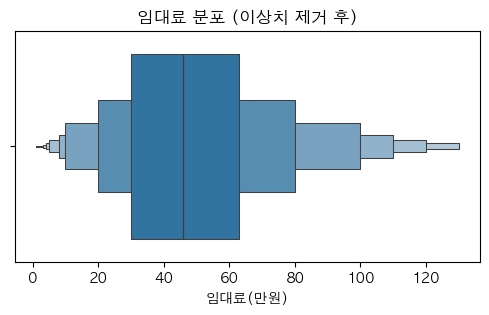

In [240]:
# 음수 및 임대료가 없는 경우 제거
df = df[df['임대료(만원)'] > 0]

# 이상치 제거
q1 = df['임대료(만원)'].quantile(0.25)
q3 = df['임대료(만원)'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr ; upper_bound = q3 + 1.5 * iqr

df = df[(df['임대료(만원)'] >= lower_bound) & (df['임대료(만원)'] <= upper_bound)]

plt.figure(figsize=(6, 3))
sns.boxenplot(x=df['임대료(만원)'])
plt.title('임대료 분포 (이상치 제거 후)')
plt.show()

### 보증금 분포

Text(0.5, 1.0, '보증금 분포')

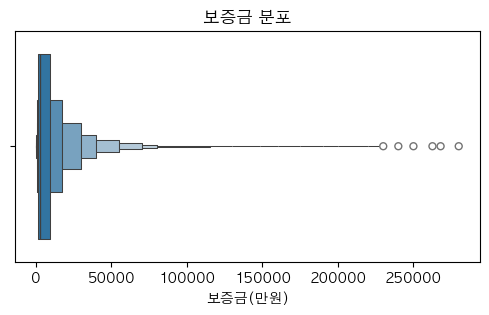

In [241]:
plt.figure(figsize=(6, 3))
sns.boxenplot(x=df['보증금(만원)'])
plt.title('보증금 분포')

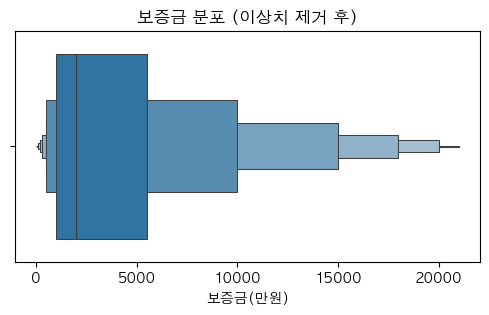

In [242]:
# 음수 보증금 제거
df = df[df['보증금(만원)'] > 0]


# 이상치 제거
q1 = df['보증금(만원)'].quantile(0.25)
q3 = df['보증금(만원)'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr ; upper_bound = q3 + 1.5 * iqr
df = df[(df['보증금(만원)'] >= lower_bound) & (df['보증금(만원)'] <= upper_bound)]

plt.figure(figsize=(6, 3))
sns.boxenplot(x=df['보증금(만원)'])
plt.title('보증금 분포 (이상치 제거 후)')
plt.show()

## Feature Engineering

### 단위면적당 월세

월세 가격을 공정하게 비교하기 위해 표준화 작업을 실시
- 월세를 면적으로 나누어 1제곱미터 당 가격 계산

In [243]:
# 단위면적당 월세 계산
df['단위면적당_월세'] = df['임대료(만원)'] / df['임대면적']

# 무한대 및 NaN 값 제거
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['단위면적당_월세'])

print("'단위면적당_월세' 컬럼 생성 완료!")
print(df[['임대면적', '임대료(만원)', '단위면적당_월세']].head())

'단위면적당_월세' 컬럼 생성 완료!
     임대면적  임대료(만원)  단위면적당_월세
3   16.13       24  1.487911
10  15.84        5  0.315657
13  28.80       60  2.083333
14  28.80       10  0.347222
15  28.80       50  1.736111


### 대학가 컬럼 생성

In [244]:
print("법정동명을 기준으로 '대학가' 변수 생성 및 데이터 필터링 중...")

# 1. '대학가'라는 새로운 컬럼을 생성
df['대학가'] = ''

# 2. 각 대학가에 해당하는 법정동 목록을 정의
univ_dong_map = {
    '서울시립대': ['전농동', '답십리동', '휘경동', '청량리동'],
    '서울교대': ['서초동'],
    '서울대': ['신림동', '봉천동'],
    '홍익대': ['상수동', '서교동', '합정동']
}

# 3. 각 대학가의 법정동에 해당하는 행에 '대학가' 이름을 부여
for univ_name, dong_list in univ_dong_map.items():
    mask = df['법정동명'].isin(dong_list)
    df.loc[mask, '대학가'] = univ_name

# 4. '대학가' 컬럼이 비어있지 않은 행만 선택하여 새로운 데이터프레임 생성
df_analysis = df[df['대학가'] != ''].copy()

print("   - 생성 및 필터링 완료!")

# --- 최종 결과 확인 ---
print("\n--- 최종 분석용 데이터 정보 ---")
df_analysis.info()

print("\n--- 각 대학가별 데이터 개수 ---")
print(df_analysis['대학가'].value_counts())

print("\n--- 최종 데이터 샘플 (상위 5개) ---")
# '법정동명'이 '대학가'에 잘 매칭되었는지 확인
print(df_analysis[['자치구명', '법정동명', '대학가', '단위면적당_월세']].head())

법정동명을 기준으로 '대학가' 변수 생성 및 데이터 필터링 중...
   - 생성 및 필터링 완료!

--- 최종 분석용 데이터 정보 ---
<class 'pandas.core.frame.DataFrame'>
Index: 153058 entries, 173 to 3557662
Data columns (total 11 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   접수년도      153058 non-null  int64  
 1   자치구명      153058 non-null  object 
 2   법정동명      153058 non-null  object 
 3   전월세구분     153058 non-null  object 
 4   임대면적      153058 non-null  float64
 5   보증금(만원)   153058 non-null  int64  
 6   임대료(만원)   153058 non-null  int64  
 7   건물용도      153058 non-null  object 
 8   건축년도      153058 non-null  float64
 9   단위면적당_월세  153058 non-null  float64
 10  대학가       153058 non-null  object 
dtypes: float64(3), int64(3), object(5)
memory usage: 14.0+ MB

--- 각 대학가별 데이터 개수 ---
대학가
서울대      105253
서울시립대     23703
서울교대      12111
홍익대       11991
Name: count, dtype: int64

--- 최종 데이터 샘플 (상위 5개) ---
    자치구명 법정동명  대학가  단위면적당_월세
173  관악구  신림동  서울대  2.217295
177  관악구  신림동  서울대  0.24067

# EDA

### 대학가별 단위면적당 월세 분포 확인

In [187]:
print(df_analysis['대학가'].value_counts())

대학가
서울대      105253
서울시립대     23703
서울교대      12111
홍익대       11991
Name: count, dtype: int64


In [188]:
# '단위면적당_월세'의 기술 통계량 확인
print(df_analysis['단위면적당_월세'].describe())

count    153058.000000
mean          1.856737
std           1.086845
min           0.014215
25%           1.008573
50%           1.755448
75%           2.511533
max          12.054507
Name: 단위면적당_월세, dtype: float64


### Correlation Plot

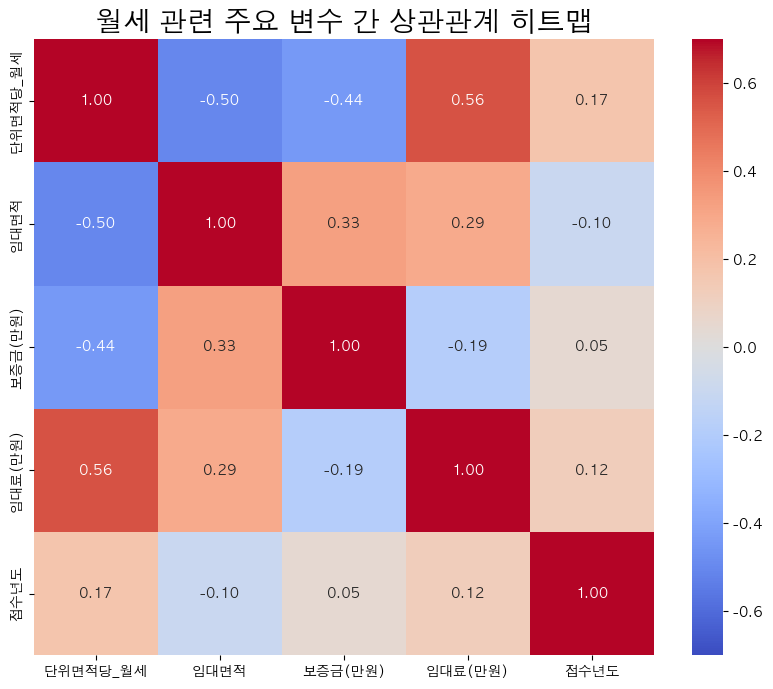

In [189]:
# 1. 수치형 변수 선택
numerical_cols = ['단위면적당_월세', '임대면적', '보증금(만원)', '임대료(만원)', '접수년도']
correlation_data = df_analysis[numerical_cols]

# 2. 상관 행렬 계산
correlation_matrix = correlation_data.corr()

# 3. 히트맵으로 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-0.7, vmax=0.7)
plt.title('월세 관련 주요 변수 간 상관관계 히트맵', fontsize=20)
plt.show()

### 대학가별 단위면적당 월세 분포 Violin Plot

/var/folders/1f/xp49wx494s78pwbz7rqgscp80000gn/T/ipykernel_88829/1926563231.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='대학가', y='단위면적당_월세', data=df_analysis,


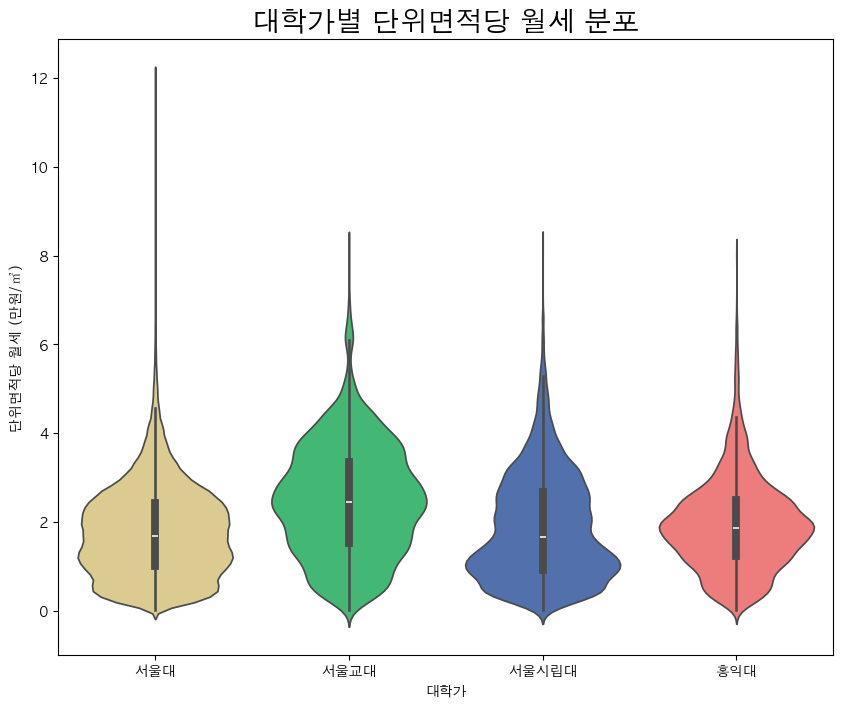

In [190]:
# plotting
plt.figure(figsize=(10, 8))
sns.violinplot(x='대학가', y='단위면적당_월세', data=df_analysis, 
               palette=['#E8D284', '#2ECC71', '#436BBA', '#FF6B6B'])
plt.title('대학가별 단위면적당 월세 분포', fontsize=20)
plt.xlabel('대학가')
plt.ylabel('단위면적당 월세 (만원/㎡)')
plt.show()

### 평균비교

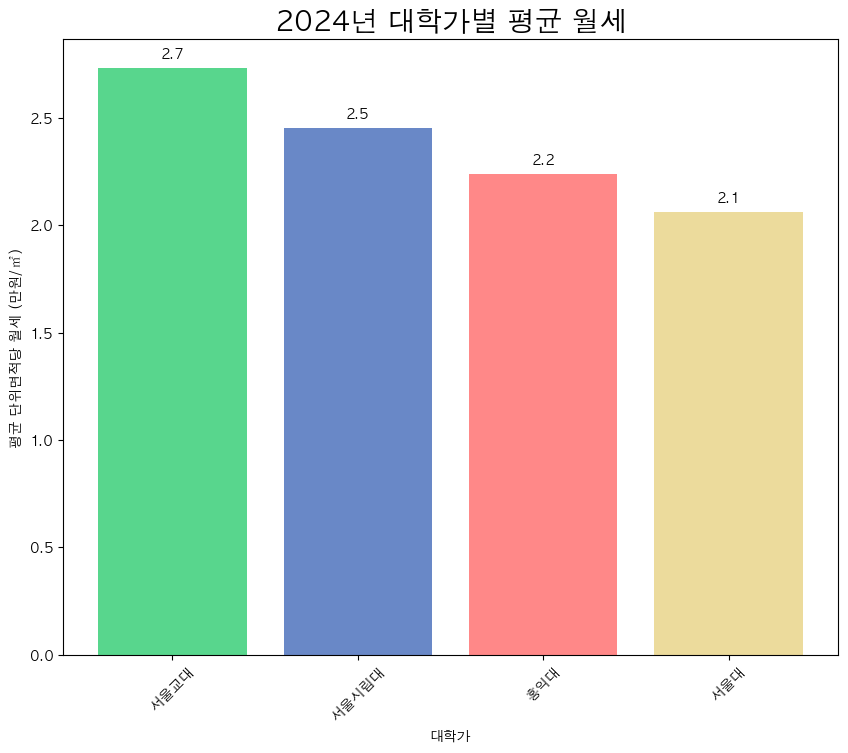

In [191]:
# 2024년 데이터 만 필터링
df_all_univ_2024 = df_analysis[df_analysis['접수년도'] == 2024]

# 평균 비교 막대그래프
plt.figure(figsize=(10, 8))
mean_by_univ = df_all_univ_2024.groupby('대학가')['단위면적당_월세'].mean().sort_values(ascending=False)
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
bars = plt.bar(mean_by_univ.index, mean_by_univ.values, color=['#2ECC71', '#436BBA', '#FF6B6B', '#E8D284'], alpha=0.8)
plt.title('2024년 대학가별 평균 월세', fontsize=20)
plt.xlabel('대학가')
plt.ylabel('평균 단위면적당 월세 (만원/㎡)')
plt.xticks(rotation=45)

# 막대 위에 수치 표시
for bar, value in zip(bars, mean_by_univ.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03, 
             f'{value:.1f}', ha='center', va='bottom', fontweight='bold')

plt.show()


## 신뢰도 분석

### Bootstrap

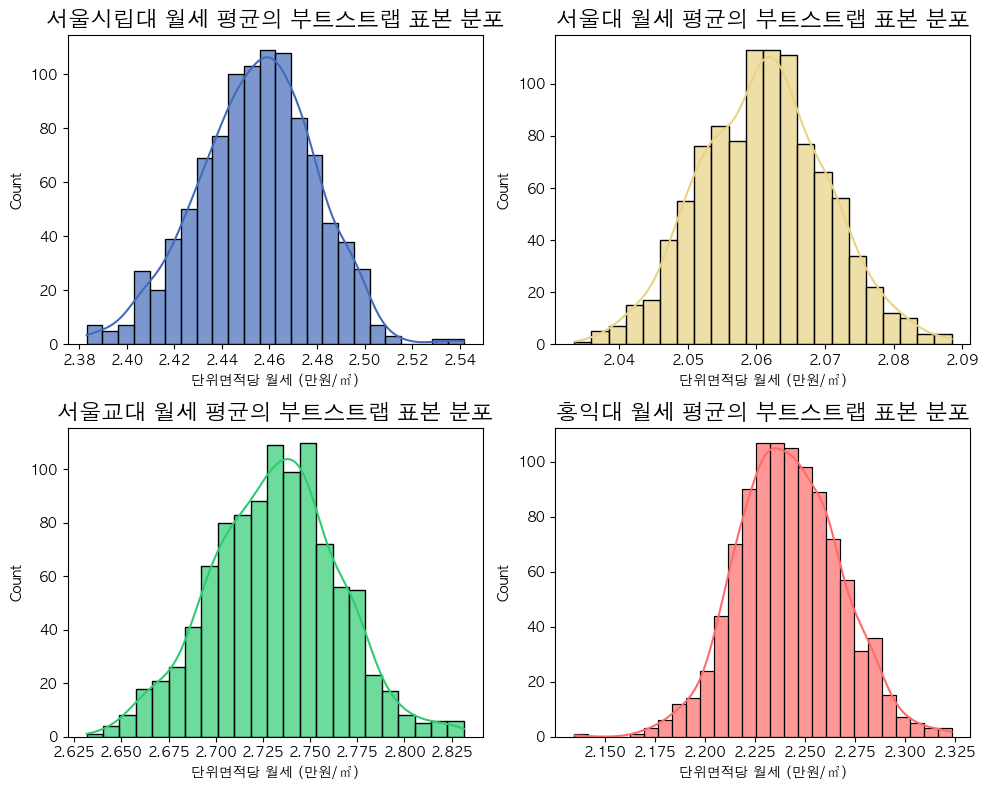

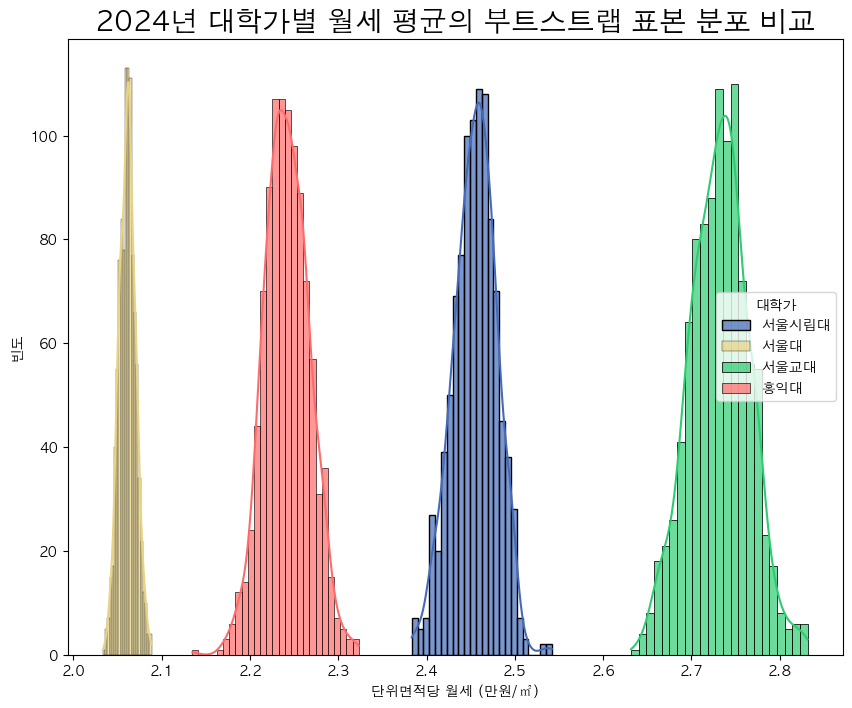

In [192]:
# 2024년 각 대학가별 데이터 분리
df_seoul_city_2024 = df_all_univ_2024[df_all_univ_2024['대학가'] == '서울시립대']
df_seoul_nat_2024 = df_all_univ_2024[df_all_univ_2024['대학가'] == '서울대']
df_seoul_edu_2024 = df_all_univ_2024[df_all_univ_2024['대학가'] == '서울교대']
df_hongik_2024 = df_all_univ_2024[df_all_univ_2024['대학가'] == '홍익대']

# 모든 대학가에 대해 부트스트랩 수행
universities = ['서울시립대', '서울대', '서울교대', '홍익대']
datasets = [df_seoul_city_2024, df_seoul_nat_2024, 
            df_seoul_edu_2024, df_hongik_2024]
bootstrap_results = {}

for univ, data in zip(universities, datasets):
    bootstrap_means = []
    for _ in range(1000):
        sample = data['단위면적당_월세'].sample(n=len(data), replace=True)
        bootstrap_means.append(sample.mean())
    bootstrap_results[univ] = bootstrap_means

# 시각화
plt.figure(figsize=(10, 8))

colors=['#436BBA', '#E8D284', '#2ECC71', '#FF6B6B']

# 개별 대학가별 부트스트랩 분포
for i, (univ, color) in enumerate(zip(universities, colors)):
    plt.subplot(2, 2, i+1)
    sns.histplot(bootstrap_results[univ], kde=True, alpha=0.7, color=color)
    plt.title(f'{univ} 월세 평균의 부트스트랩 표본 분포', fontsize=16)
    plt.xlabel('단위면적당 월세 (만원/㎡)')

plt.tight_layout()
plt.show()

# 모든 대학가 부트스트랩 결과를 하나의 그래프로 비교
plt.figure(figsize=(10, 8))

for univ, color in zip(universities, colors):
    sns.histplot(bootstrap_results[univ], kde=True, alpha=0.7, label=univ, color=color)

plt.title('2024년 대학가별 월세 평균의 부트스트랩 표본 분포 비교', fontsize=20)
plt.xlabel('단위면적당 월세 (만원/㎡)')
plt.ylabel('빈도')
plt.legend(title='대학가')
plt.show()

### 각 대학별 95% 신뢰구간 계산

In [193]:
for univ in universities:
    bootstrap_means_univ = bootstrap_results[univ]
    
    # 95% 신뢰구간 계산
    lower_bound = np.percentile(bootstrap_means_univ, 2.5)
    upper_bound = np.percentile(bootstrap_means_univ, 97.5)
    
    # 표준오차 계산
    std_error = np.std(bootstrap_means_univ)
    
    # 평균 계산
    mean_val = np.mean(bootstrap_means_univ)
    
    print(f"=== {univ} ===")
    print(f"단위면적당 월세 평균: {mean_val:.2f} 만원")
    print(f"95% 신뢰구간: [{lower_bound:.2f}, {upper_bound:.2f}] 만원")
    print(f"표준오차: {std_error:.2f} 만원")
    print()

=== 서울시립대 ===
단위면적당 월세 평균: 2.45 만원
95% 신뢰구간: [2.41, 2.50] 만원
표준오차: 0.02 만원

=== 서울대 ===
단위면적당 월세 평균: 2.06 만원
95% 신뢰구간: [2.04, 2.08] 만원
표준오차: 0.01 만원

=== 서울교대 ===
단위면적당 월세 평균: 2.73 만원
95% 신뢰구간: [2.66, 2.80] 만원
표준오차: 0.03 만원

=== 홍익대 ===
단위면적당 월세 평균: 2.24 만원
95% 신뢰구간: [2.19, 2.29] 만원
표준오차: 0.03 만원



### QQ plot

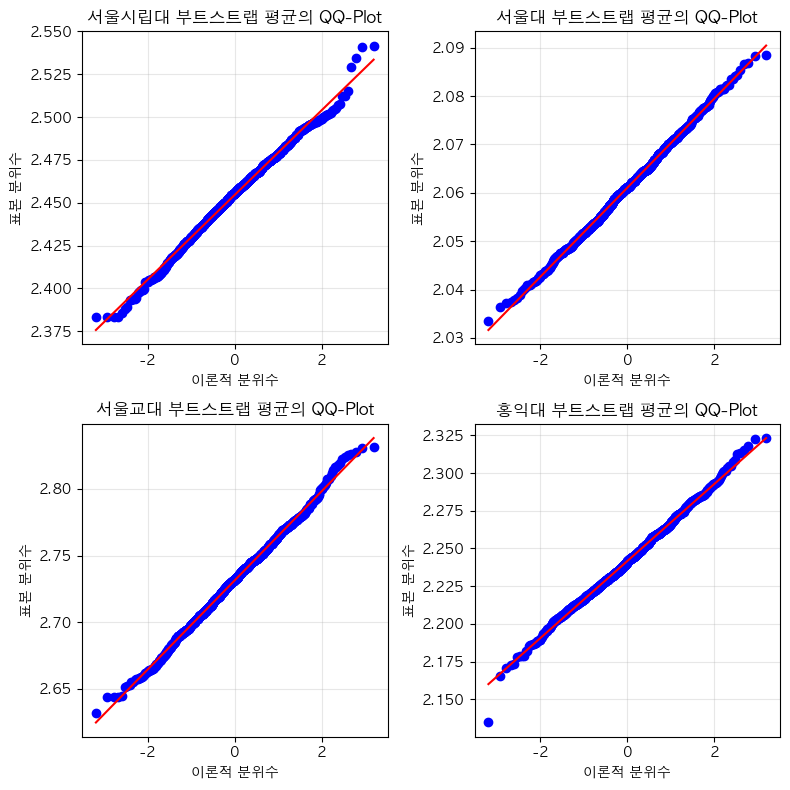

In [194]:
from scipy import stats

plt.figure(figsize=(8, 8))

# 각 대학가별 QQ-Plot
for i, univ in enumerate(universities):
    plt.subplot(2, 2, i+1)
    stats.probplot(bootstrap_results[univ], dist="norm", plot=plt)
    plt.title(f'{univ} 부트스트랩 평균의 QQ-Plot')
    plt.xlabel('이론적 분위수')
    plt.ylabel('표본 분위수')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 연도별 대학가 단위면적당 월세 변화 분석

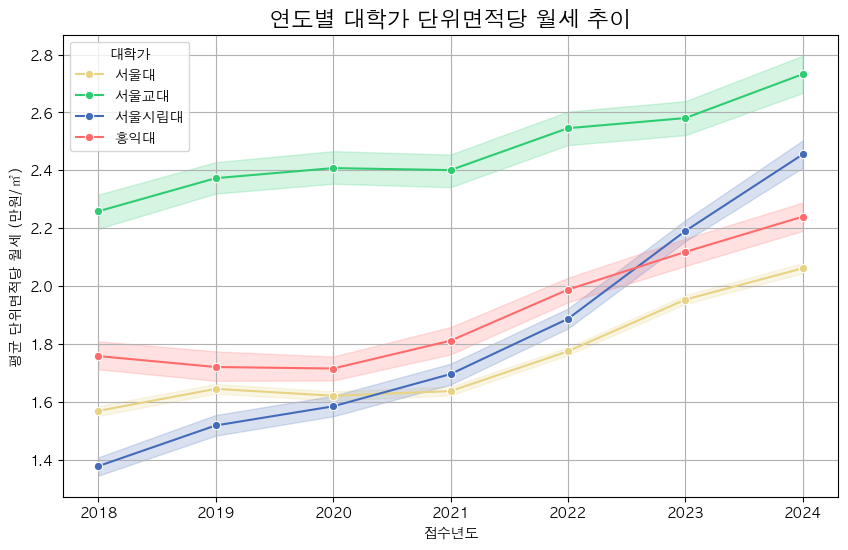

In [195]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='접수년도', y='단위면적당_월세', hue='대학가', data=df_analysis, estimator=np.mean, palette=['#E8D284', '#2ECC71', '#436BBA', '#FF6B6B'], marker='o')
plt.title('연도별 대학가 단위면적당 월세 추이', fontsize=16)
plt.ylabel('평균 단위면적당 월세 (만원/㎡)')
plt.grid(True)
plt.show()

### 월세 증가율

/var/folders/1f/xp49wx494s78pwbz7rqgscp80000gn/T/ipykernel_88829/1788425414.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=sorted_increase_rate.index, y=sorted_increase_rate.values, order=sorted_increase_rate.index, palette=['#436BBA', '#E8D284', '#FF6B6B', '#2ECC71'])


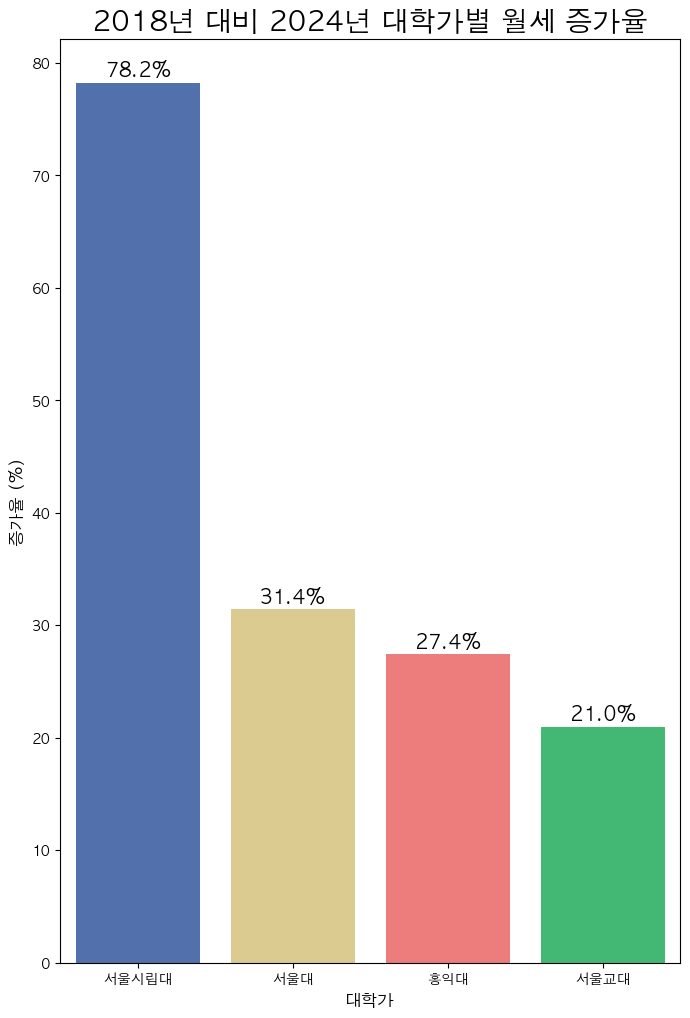

In [196]:
# 1. 증가율 계산
start_year = df_analysis['접수년도'].min()
end_year = df_analysis['접수년도'].max()

rent_start = df_analysis[df_analysis['접수년도'] == start_year].groupby('대학가')['단위면적당_월세'].mean()
rent_end = df_analysis[df_analysis['접수년도'] == end_year].groupby('대학가')['단위면적당_월세'].mean()

increase_rate = ((rent_end - rent_start) / rent_start) * 100

# 2. 증가율을 내림차순으로 정렬
sorted_increase_rate = increase_rate.sort_values(ascending=False)

# 3. 막대그래프로 시각화
plt.figure(figsize=(8, 12))
ax = sns.barplot(x=sorted_increase_rate.index, y=sorted_increase_rate.values, order=sorted_increase_rate.index, palette=['#436BBA', '#E8D284', '#FF6B6B', '#2ECC71'])

# 그래프 제목 및 축 레이블 설정
plt.title(f'{start_year}년 대비 {end_year}년 대학가별 월세 증가율', fontsize=20)
plt.ylabel('증가율 (%)', fontsize=12)
plt.xlabel('대학가', fontsize=12)
plt.xticks(rotation=0)

# 막대 위에 퍼센트 수치 표시
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',    # 표시할 텍스트
                (p.get_x() + p.get_width() / 2., p.get_height()), # 텍스트 위치
                ha='center', va='center',   # 정렬
                xytext=(0, 9),              # 막대 끝에서 약간 위로
                textcoords='offset points',
                fontsize=14)                
plt.show()

# Hypothesis test 

## 가설1 
: 2024년도 평균월세 차이는 과연 통계적으로 유의미한가? 

In [197]:
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

df_2024 = df_all_univ_2024.copy()

### 가설 1-A: 서울교대 vs. 서울대 (두 그룹 비교, t-test)

- 평균 월세가 가장 많이 차이나는 두 그룹을 비교

귀무가설($H_0$): $\mu_{서울교대} = \mu_{서울대}$ (두 대학가 간 평균 월세 차이가 없다.)

대립가설($H_1$): $\mu_{서울교대} > \mu_{서울대}$ (서울교대 인근 평균 월세가 더 비싸다.)

In [198]:
# --- [ 가설 1-A 검증: Independent Two-sample t-test ] ---
print("--- 🔬 가설 1-A 검증 (서울교대 vs 서울시립대) ---")

# 1. 각 그룹의 샘플 데이터를 추출
rent_snu_edu = df_2024[df_2024['대학가'] == '서울교대']['단위면적당_월세']
rent_snu = df_2024[df_2024['대학가'] == '서울시립대']['단위면적당_월세']

# 2. 등분산성 검정 (Levene's Test)
#    - p-value가 0.05보다 작으면 분산이 다르다고 가정 (equal_var=False).
levene_stat, levene_p = stats.levene(rent_snu_edu, rent_snu)
equal_var_flag = levene_p > 0.05 # True이면 등분산 가정, False이면 이분산 가정(Welch's T-test)

print(f"[등분산성 검정] p-value: {levene_p:.4f} (equal_var={equal_var_flag})")

# 3. Independent Two-sample t-test 수행
#    - alternative='greater': 서울교대(첫번째 인자)의 평균이 서울시립대(두번째 인자)보다 크다는 단측 검정
t_stat_1a, p_val_1a = stats.ttest_ind(
    rent_snu_edu, 
    rent_snu, 
    equal_var=equal_var_flag, 
    alternative='greater'
)

print(f"t-statistic: {t_stat_1a:.4f}")
print(f"p-value: {p_val_1a:.4f}")

# 4. 결과 해석
alpha = 0.05
if p_val_1a < alpha:
    print(f"▶ 결론: p-value({p_val_1a:.4f})가 유의수준({alpha})보다 작으므로 귀무가설을 기각합니다.")
    print("   따라서, 2024년 기준 서울교대 인근의 평균 월세는 서울시립대 인근보다 통계적으로 유의미하게 비쌉니다.")
else:
    print(f"▶ 결론: p-value({p_val_1a:.4f})가 유의수준({alpha})보다 크므로 귀무가설을 기각할 수 없습니다.")
    print("   따라서, 2024년 기준 서울교대 인근의 평균 월세가 서울시립대 인근보다 유의미하게 비싸다고 말할 수 없습니다.")

--- 🔬 가설 1-A 검증 (서울교대 vs 서울시립대) ---
[등분산성 검정] p-value: 0.0286 (equal_var=False)
t-statistic: 6.6039
p-value: 0.0000
▶ 결론: p-value(0.0000)가 유의수준(0.05)보다 작으므로 귀무가설을 기각합니다.
   따라서, 2024년 기준 서울교대 인근의 평균 월세는 서울시립대 인근보다 통계적으로 유의미하게 비쌉니다.


--- 📊 가설 1-A 시각화 (서울교대 vs 서울대) ---


/var/folders/1f/xp49wx494s78pwbz7rqgscp80000gn/T/ipykernel_88829/844650694.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


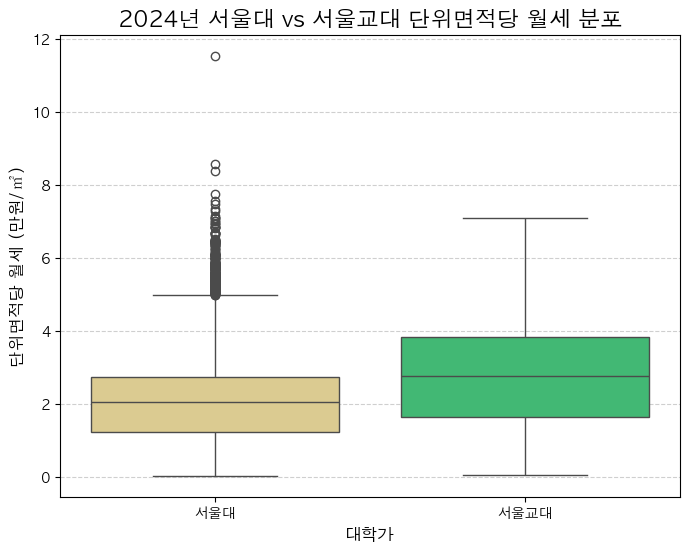

In [199]:
# --- [ 가설 1-A 시각화: Box Plot ] ---
print("--- 📊 가설 1-A 시각화 (서울교대 vs 서울대) ---")

# 1. t-test에 사용된 두 그룹('서울대', '서울교대') 데이터만 필터링
df_1a_viz = df_2024[df_2024['대학가'].isin(['서울대', '서울교대'])]

# 2. Box Plot으로 두 그룹의 분포를 시각화
plt.figure(figsize=(8, 6))
sns.boxplot(
    x='대학가', 
    y='단위면적당_월세', 
    data=df_1a_viz, 
    palette=['#E8D284', '#2ECC71'], # EDA.ipynb의 [22]번 셀 색상 팔레트와 일치
    order=['서울대', '서울교대'] # 순서 지정
)

plt.title('2024년 서울대 vs 서울교대 단위면적당 월세 분포', fontsize=16)
plt.xlabel('대학가', fontsize=12)
plt.ylabel('단위면적당 월세 (만원/㎡)', fontsize=12)
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.show()

### 가설 1-B: 4개 대학가 전체 비교 (ANOVA)

귀무가설($H_0$): $\mu_{서울교대} = \mu_{서울시립대} = \mu_{서울대} = \mu_{홍익대}$ 
    (모든 대학가 간 평균 월세가 동일하다.)

대립가설($H_1$): 모든 대학가의 평균 월세가 동일한 것은 아니다. (적어도 하나는 다르다.)

In [200]:
# --- [ 가설 1-B 검증: ANOVA 및 Tukey's HSD 사후 검정 ] ---
print("\n--- 가설 1-B 검증 (4개 대학가 전체 비교) ---")

# 1. ANOVA 검증을 위해 나머지 대학가 데이터도 추출
rent_uos = df_2024[df_2024['대학가'] == '서울시립대']['단위면적당_월세']
rent_hongik = df_2024[df_2024['대학가'] == '홍익대']['단위면적당_월세']

# 2. 일원배치 분산분석 (One-way ANOVA) 수행
f_stat_1b, p_val_1b = stats.f_oneway(rent_snu_edu, rent_snu, rent_uos, rent_hongik)

print(f"[ANOVA 검증] F-statistic: {f_stat_1b:.4f}")
print(f"p-value: {p_val_1b:.4f}")

# 3. ANOVA 결과 해석
if p_val_1b < alpha:
    print(f"▶ 결론: p-value({p_val_1b:.4f})가 유의수준({alpha})보다 작으므로 귀무가설을 기각합니다.")
    print("   따라서, 4개 대학가 간 평균 월세는 통계적으로 유의미한 차이가 있습니다.")
    print("\n   [사후 검정 (Tukey's HSD) 수행] - 어느 그룹 간에 차이가 있는지 확인합니다.")
    
    # 4. 사후 검정 (Tukey's HSD)
    #    - ANOVA가 유의미할 때만 실행하여 어떤 그룹끼리 차이가 나는지 확인
    tukey_result = pairwise_tukeyhsd(
        df_2024['단위면적당_월세'], 
        df_2024['대학가'], 
        alpha=0.05
    )
    
    print(tukey_result)
    
else:
    print(f"▶ 결론: p-value({p_val_1b:.4f})가 유의수준({alpha})보다 크므로 귀무가설을 기각할 수 없습니다.")
    print("   따라서, 4개 대학가 간 평균 월세 차이가 통계적으로 유의미하다고 말할 수 없습니다.")


--- 가설 1-B 검증 (4개 대학가 전체 비교) ---
[ANOVA 검증] F-statistic: 37.7274
p-value: 0.0000
▶ 결론: p-value(0.0000)가 유의수준(0.05)보다 작으므로 귀무가설을 기각합니다.
   따라서, 4개 대학가 간 평균 월세는 통계적으로 유의미한 차이가 있습니다.

   [사후 검정 (Tukey's HSD) 수행] - 어느 그룹 간에 차이가 있는지 확인합니다.
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
  서울교대    서울대  -0.6709   0.0 -0.7503 -0.5916   True
  서울교대  서울시립대  -0.2772   0.0 -0.3688 -0.1855   True
  서울교대    홍익대  -0.4925   0.0 -0.5949   -0.39   True
   서울대  서울시립대   0.3938   0.0  0.3364  0.4511   True
   서울대    홍익대   0.1785   0.0   0.105  0.2519   True
 서울시립대    홍익대  -0.2153   0.0 -0.3019 -0.1287   True
---------------------------------------------------


--- 📊 가설 1-B 시각화 (Tukey's HSD 사후 검정) ---


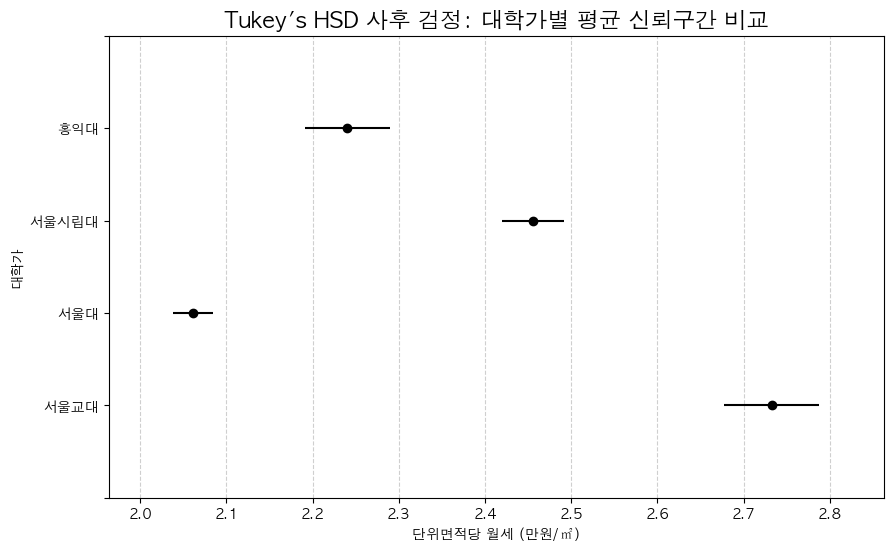

In [201]:
# --- [ 가설 1-B 시각화: Tukey's HSD Plot ] ---
print("--- 📊 가설 1-B 시각화 (Tukey's HSD 사후 검정) ---")

# 1. Tukey HSD 결과를 시각화합니다. (tukey_result 객체는 이전 셀에서 생성되어 있어야 함)
#    이 플롯은 각 그룹의 '평균'에 대한 95% 신뢰구간을 보여줍니다.
try:
    fig = tukey_result.plot_simultaneous(
        figsize=(10, 6), 
        xlabel='단위면적당 월세 (만원/㎡)',
        ylabel='대학가'
    )
    plt.title("Tukey's HSD 사후 검정: 대학가별 평균 신뢰구간 비교", fontsize=16)
    plt.grid(True, axis='x', linestyle='--', alpha=0.6)
    plt.show()

except NameError:
    print("오류: 'tukey_result' 객체가 정의되지 않았습니다. [가설 1-B] 코드를 먼저 실행하세요.")

▶ 위 결과에 따라 각 그룹 간의 차이가 모두 통계적으로 유의미한 차이임을 알 수 있다.

## 가설 2
: 서울시립대 인근의 '가파른 월세 상승' 검증

In [202]:
import statsmodels.formula.api as smf

# 전체 기간 데이터 사용
df_full = df_analysis.copy()

### 가설 2-A: 2021년 전/후 시점 비교 (A/B 테스트)

서울시립대 인근의 평균 월세는 2021년을 기점으로 통계적으로 유의미하게 상승했는가?

귀무가설($H_0$): $\mu_{2021이후} = \mu_{2021이전}$ (2021년 전후의 평균 월세 차이가 없다.)
     
대립가설($H_1$): $\mu_{2021이후} > \mu_{2021이전}$ (2021년 이후 평균 월세가 더 높다.)

In [203]:
# 간단 주석 버전
print("--- 🔬 가설 2-A 검증 (서울시립대 2021년 전/후 비교) ---")

# 서울시립대 데이터만
df_uos_full = df_full[df_full['대학가'] == '서울시립대']

# 2020년까지 = 이전, 2021년부터 = 이후
rent_pre_2021 = df_uos_full[df_uos_full['접수년도'] <= 2020]['단위면적당_월세']
rent_post_2021 = df_uos_full[df_uos_full['접수년도'] >= 2021]['단위면적당_월세']

# 등분산성 검사
levene_stat_2a, levene_p_2a = stats.levene(rent_post_2021, rent_pre_2021)
equal_var_flag_2a = levene_p_2a > 0.05
print(f"[등분산성 검정] p-value: {levene_p_2a:.4f} (equal_var={equal_var_flag_2a})")

# 단측 t-test: 이후 > 이전
t_stat_2a, p_val_2a = stats.ttest_ind(
    rent_post_2021,
    rent_pre_2021,
    equal_var=equal_var_flag_2a,
    alternative='greater'
)

print(f"t-statistic: {t_stat_2a:.4f}")
print(f"p-value: {p_val_2a:.4f}")

# 해석 (alpha는 이전 셀에서 정의한 값 사용)
if p_val_2a < alpha:
    print(f"▶ 결론: p-value({p_val_2a:.4f}) < {alpha} → 귀무가설 기각. 2021년 이후 상승이 유의미함.")
else:
    print(f"▶ 결론: p-value({p_val_2a:.4f}) >= {alpha} → 귀무가설 기각 불가. 유의한 상승 아님.")


--- 🔬 가설 2-A 검증 (서울시립대 2021년 전/후 비교) ---
[등분산성 검정] p-value: 0.0000 (equal_var=False)
t-statistic: 39.4605
p-value: 0.0000
▶ 결론: p-value(0.0000) < 0.05 → 귀무가설 기각. 2021년 이후 상승이 유의미함.


--- 📊 가설 2-A 시각화 (서울시립대 2021년 전/후) ---


/var/folders/1f/xp49wx494s78pwbz7rqgscp80000gn/T/ipykernel_88829/3663711558.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_uos_full['기간'] = np.where(df_uos_full['접수년도'] >= 2021, '2021년 이후', '2021년 이전')
/var/folders/1f/xp49wx494s78pwbz7rqgscp80000gn/T/ipykernel_88829/3663711558.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


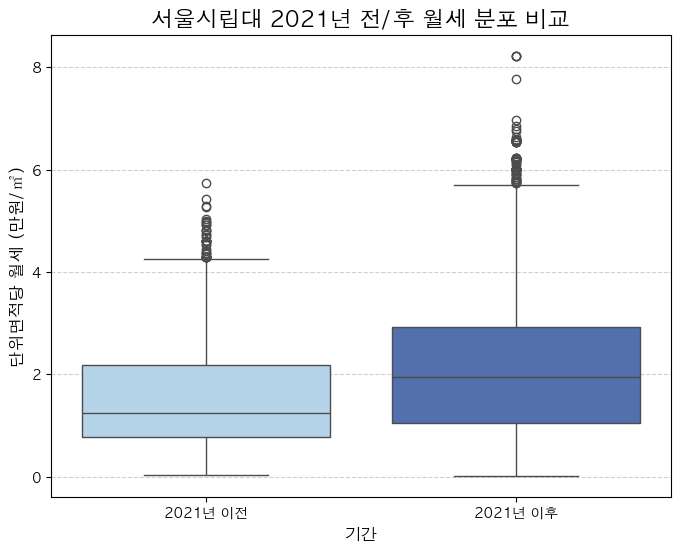

In [204]:
# --- [ 가설 2-A 시각화: Box Plot (2021년 전/후) ] ---
print("--- 📊 가설 2-A 시각화 (서울시립대 2021년 전/후) ---")

# 1. 시각화를 위해 '기간' 컬럼을 생성합니다. (df_uos_full은 이전 셀에서 생성)
df_uos_full['기간'] = np.where(df_uos_full['접수년도'] >= 2021, '2021년 이후', '2021년 이전')

# 2. Box Plot으로 두 기간의 분포를 시각화
plt.figure(figsize=(8, 6))
sns.boxplot(
    x='기간', 
    y='단위면적당_월세', 
    data=df_uos_full,
    palette=['#AED6F1', '#436BBA'], # 이전/이후 색상 지정
    order=['2021년 이전', '2021년 이후'] # 순서 지정
)

plt.title('서울시립대 2021년 전/후 월세 분포 비교', fontsize=16)
plt.xlabel('기간', fontsize=12)
plt.ylabel('단위면적당 월세 (만원/㎡)', fontsize=12)
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.show()

### 가설 2-B: 타 대학가와의 '상승 추세' 비교 (회귀분석)

2021년 이후, 서울시립대 인근의 월세 상승폭은 서울대(대조군) 인근의 상승폭보다 통계적으로 유의미하게 더 컸는가?

귀무가설($H_0$): $\beta_3 = 0$ (서울시립대만의 추가적인 월세 상승 효과는 없다.)

대립가설($H_1$): $\beta_3 > 0$ (서울시립대만의 추가적인 월세 상승 효과가 유의미하게 존재한다.)

In [205]:
# --- [ 가설 2-B 검증: 회귀분석 (Difference-in-Differences) ] ---
print("\n--- 🔬 가설 2-B 검증 (서울시립대 vs 서울대 상승폭 비교) ---")

# 서울대와 서울시립대 데이터만 사용
df_did = df_full[df_full['대학가'].isin(['서울대', '서울시립대'])].copy()

# 더미 변수 생성: 2021년 이후, 서울시립대 여부
df_did['is_Post2021'] = (df_did['접수년도'] >= 2021).astype(int)
df_did['is_UOS'] = (df_did['대학가'] == '서울시립대').astype(int)

# DiD 회귀모형 (interaction 포함)
model = smf.ols(formula='단위면적당_월세 ~ is_Post2021 * is_UOS', data=df_did).fit()

# 결과 출력
print(model.summary())

# 상호작용항의 계수와 p-value 추출
interaction_term = 'is_Post2021:is_UOS'
interaction_coef = model.params[interaction_term]
interaction_pvalue = model.pvalues[interaction_term]

print(f"\n--- [ {interaction_term} ] 상호작용항 ---")
print(f"계수: {interaction_coef:.4f}")
print(f"p-value (양측): {interaction_pvalue:.4e}")

# 단측검정: 계수가 양수이고 (양측 p-value / 2) < alpha 이면 유의
p_val_one_sided = interaction_pvalue / 2

if (interaction_coef > 0) and (p_val_one_sided < alpha):
    print(f"▶ 결론: 계수 양수({interaction_coef:.4f})이고 단측 p-value({p_val_one_sided:.4e}) < {alpha} → 유의합니다.")
    print("   즉, 서울시립대의 2021년 이후 상승폭이 서울대보다 컸습니다.")
else:
    print("▶ 결론: 귀무가설을 기각할 수 없습니다. 서울시립대의 상승폭이 유의하게 더 크다고 보기 어렵습니다.")



--- 🔬 가설 2-B 검증 (서울시립대 vs 서울대 상승폭 비교) ---
                            OLS Regression Results                            
Dep. Variable:               단위면적당_월세   R-squared:                       0.024
Model:                            OLS   Adj. R-squared:                  0.024
Method:                 Least Squares   F-statistic:                     1044.
Date:                Tue, 02 Dec 2025   Prob (F-statistic):               0.00
Time:                        18:37:52   Log-Likelihood:            -1.8849e+05
No. Observations:              128956   AIC:                         3.770e+05
Df Residuals:                  128952   BIC:                         3.770e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------

▶ 회귀분석 결과, '서울시립대이면서 2021년 이후'를 나타내는 항의 계수가 +0.3057, 이 값의 p-valuerk 0.000 이다.

▶ 이는 2021년 이후 서울대, 홍익대, 서울교대 등 다른 대학가들이 공통적으로 겪은 월세 상승분(시간 효과, 0.4414)을 모두 제외하고도, 서울시립대 인근만 추가적으로 0.34 (만원/㎡)만큼 더 폭등했음을 의미

### 가설 3: 2025년 서울시립대와 홍익대 단위면적당 월세 평균 가설검정
- $\mu_{서울시립대} = \mu_{홍익대}$
- $\mu_{서울시립대} \neq \mu_{홍익대}$
- $\mu_{홍익대} - \mu_{서울시립대}$에 대해서 순열검정 구현

#### 2025년도 대학가별 단위면적당 월세 분포 확인

In [206]:
# 데이터 불러오기
df_2025 = pd.read_csv('Data/2025_hs.csv', encoding='cp949')
print(df_2025.head(3))

# 확인하고 싶은 컬럼 선택
selected_columns = ['접수연도', '자치구명', '법정동명', '전월세 구분', '임대면적(㎡)', '보증금(만원)', '임대료(만원)', '건물용도']

# 선택된 컬럼에 대한 데이터 구조 확인
target_df = df_2025[selected_columns].copy()
target_df.info()

   접수연도    자치구코드  자치구명    법정동코드   법정동명  지번구분 지번구분명     본번    부번    층  ...  \
0  2025  11560.0  영등포구  12700.0  양평동3가   1.0    대지   79.0   4.0  4.0  ...   
1  2025  11620.0   관악구  10200.0    신림동   NaN   NaN    NaN   NaN  NaN  ...   
2  2025  11500.0   강서구  10200.0    등촌동   1.0    대지  628.0  13.0  6.0  ...   

   보증금(만원) 임대료(만원)     건물명    건축년도   건물용도         계약기간  신규갱신여부 계약갱신권사용여부  \
0    41000      70    현대2차  1990.0    아파트          NaN     NaN       NaN   
1     2000     120     NaN  2016.0  단독다가구          NaN     NaN       NaN   
2     2000      45  현대프린스텔  1999.0   오피스텔  25.10~27.10      신규       NaN   

  종전 보증금 종전 임대료  
0    NaN    NaN  
1    NaN    NaN  
2    NaN    NaN  

[3 rows x 23 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 445059 entries, 0 to 445058
Data columns (total 8 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   접수연도     445059 non-null  int64  
 1   자치구명     445056 non-null  object 
 2   법정동명     445056 non-

접수연도       0
자치구명       3
법정동명       3
전월세 구분     0
임대면적(㎡)    0
보증금(만원)    0
임대료(만원)    0
건물용도       0
dtype: int64


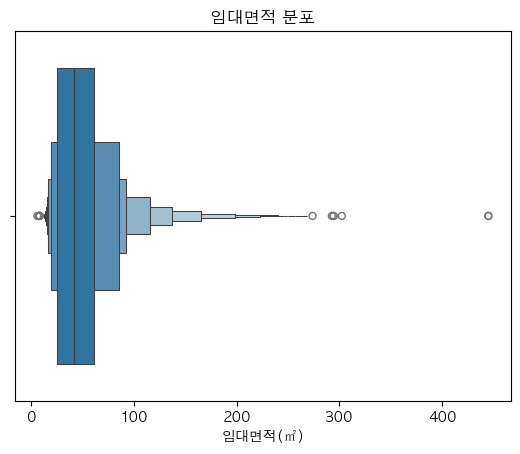

In [207]:
# 데이터 전처리
print(target_df.isnull().sum())
target_df = target_df.dropna()
target_df = target_df[target_df['임대면적(㎡)'] > 0]

sns.boxenplot(x=target_df['임대면적(㎡)'])
plt.title('임대면적 분포')
# 임대면적 이상치 제거
q1 = target_df['임대면적(㎡)'].quantile(0.25)
q3 = target_df['임대면적(㎡)'].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

target_df = target_df[(target_df['임대면적(㎡)'] >= lower_bound) & (target_df['임대면적(㎡)'] <= upper_bound)]

# 음수 및 임대료가 없는 경우 제거
target_df = target_df[target_df['임대료(만원)'] > 0]

# 임대료 이상치 제거
q1 = target_df['임대료(만원)'].quantile(0.25)
q3 = target_df['임대료(만원)'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr ; upper_bound = q3 + 1.5 * iqr

target_df = target_df[(target_df['임대료(만원)'] >= lower_bound) & (target_df['임대료(만원)'] <= upper_bound)]

# 음수 보증금 제거
target_df = target_df[target_df['보증금(만원)'] > 0]


# 보증금 이상치 제거
q1 = target_df['보증금(만원)'].quantile(0.25)
q3 = target_df['보증금(만원)'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr ; upper_bound = q3 + 1.5 * iqr
target_df = target_df[(target_df['보증금(만원)'] >= lower_bound) & (target_df['보증금(만원)'] <= upper_bound)]


In [208]:
df = target_df.reset_index().copy()
df = df.rename(columns={'임대면적(㎡)': '임대면적'})

# 단위면적당 월세
df['단위면적당_월세'] = df['임대료(만원)'] / df['임대면적']
df.info()

# 계산 결과가 inf이거나 숫자가 아닌 경우는 분석에 방해가 되므로 제거
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['단위면적당_월세'])

print("'단위면적당_월세' 컬럼 생성 완료")
print(df[['임대면적', '임대료(만원)', '단위면적당_월세']].head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 218382 entries, 0 to 218381
Data columns (total 10 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   index     218382 non-null  int64  
 1   접수연도      218382 non-null  int64  
 2   자치구명      218382 non-null  object 
 3   법정동명      218382 non-null  object 
 4   전월세 구분    218382 non-null  object 
 5   임대면적      218382 non-null  float64
 6   보증금(만원)   218382 non-null  int64  
 7   임대료(만원)   218382 non-null  int64  
 8   건물용도      218382 non-null  object 
 9   단위면적당_월세  218382 non-null  float64
dtypes: float64(2), int64(4), object(4)
memory usage: 16.7+ MB
'단위면적당_월세' 컬럼 생성 완료
    임대면적  임대료(만원)  단위면적당_월세
0  50.00      120  2.400000
1  21.66       45  2.077562
2  30.00       70  2.333333
3  31.80       20  0.628931
4  40.81       70  1.715266


In [209]:
print("법정동명을 기준으로 '대학가' 변수 생성 및 데이터 필터링 중...")

# 1. 대학가 컬럼 생성
df['대학가'] = ''

# 2. 각 대학가에 해당하는 법정동 목록을 정의
univ_dong_map = {
    '서울시립대': ['전농동', '답십리동', '휘경동', '청량리동'],
    '서울교대': ['서초동'],
    '서울대': ['신림동', '봉천동'],
    '홍익대': ['상수동', '서교동', '합정동']
}

# 3. 각 대학가의 법정동에 해당하는 행에 '대학가' 이름을 부여
for univ_name, dong_list in univ_dong_map.items():
    mask = df['법정동명'].isin(dong_list)
    df.loc[mask, '대학가'] = univ_name

# 4. '대학가' 이름이 할당된 행들만 필터링하여 최종 분석용 데이터프레임 생성
df = df[df['대학가'] != ''].reset_index().copy()

print("   - 생성 및 필터링 완료!")

# --- 최종 결과 확인 ---
print("\n--- 최종 분석용 데이터 정보 ---")
df.info()

법정동명을 기준으로 '대학가' 변수 생성 및 데이터 필터링 중...
   - 생성 및 필터링 완료!

--- 최종 분석용 데이터 정보 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25513 entries, 0 to 25512
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   level_0   25513 non-null  int64  
 1   index     25513 non-null  int64  
 2   접수연도      25513 non-null  int64  
 3   자치구명      25513 non-null  object 
 4   법정동명      25513 non-null  object 
 5   전월세 구분    25513 non-null  object 
 6   임대면적      25513 non-null  float64
 7   보증금(만원)   25513 non-null  int64  
 8   임대료(만원)   25513 non-null  int64  
 9   건물용도      25513 non-null  object 
 10  단위면적당_월세  25513 non-null  float64
 11  대학가       25513 non-null  object 
dtypes: float64(2), int64(5), object(5)
memory usage: 2.3+ MB


In [210]:
df_uos = df[df['대학가'] == '서울시립대']
df_snu = df[df['대학가'] == '서울대']
df_snue = df[df['대학가'] == '서울교대']
df_hongik = df[df['대학가'] == '홍익대']

universities = ['서울시립대', '서울대', '서울교대', '홍익대']
datasets = [df_uos, df_snu, df_snue, df_hongik]
results = {}

for univ, data in zip(universities, datasets):
    sample_means = []
    for i in range(1000):
        sample = data['단위면적당_월세'].sample(n=len(data), replace=True)
        sample_means.append(sample.mean())
    results[univ] = sample_means

서울시립대 통계량
95% 신뢰구간: [2.3712, 2.4562]
표준오차: 0.0226
표본평균의 평균: 2.4146

서울대 통계량
95% 신뢰구간: [2.1679, 2.1992]
표준오차: 0.0082
표본평균의 평균: 2.1836

서울교대 통계량
95% 신뢰구간: [2.7793, 2.9046]
표준오차: 0.0326
표본평균의 평균: 2.8430

홍익대 통계량
95% 신뢰구간: [2.3040, 2.4091]
표준오차: 0.0267
표본평균의 평균: 2.3584



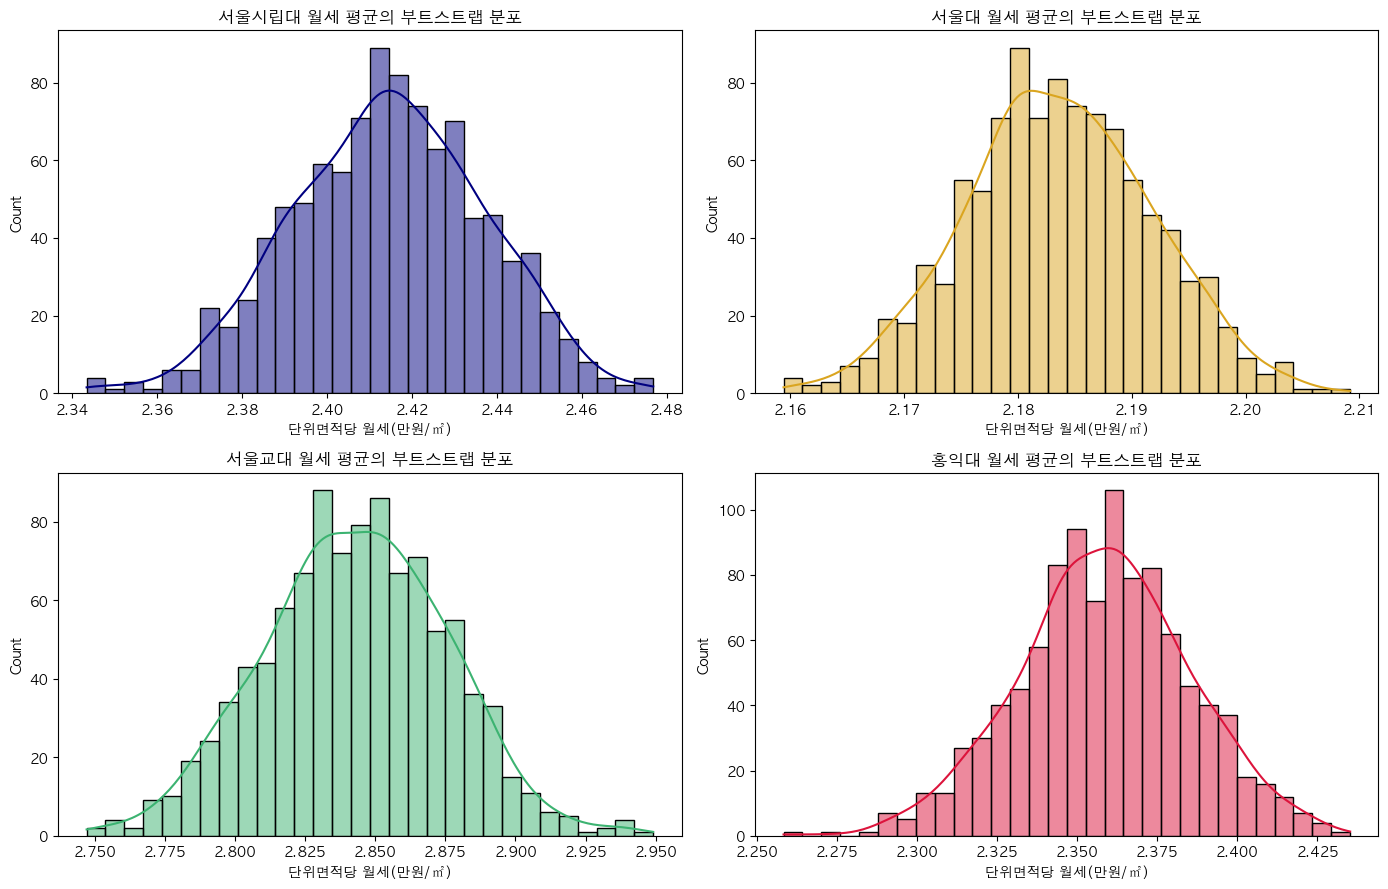

In [211]:
univ_stats = {}
colors = ['navy', 'goldenrod', 'mediumseagreen', 'crimson']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for i, (univ, sample_means) in enumerate(results.items()):
    ax = axes[i // 2, i % 2]

    sns.histplot(sample_means, kde=True, color=colors[i], ax=ax, bins=30)
    ax.set_title(f'{univ} 월세 평균의 부트스트랩 분포')
    ax.set_xlabel('단위면적당 월세(만원/㎡)')
    ax.set_ylabel('Count')

    # 95% 신뢰구간 계산
    lower_bound = np.percentile(sample_means, 2.5)
    upper_bound = np.percentile(sample_means, 97.5)

    # 표준오차 계산
    std_error = np.std(sample_means)

    # 표본평균의 평균 계산
    sample_mean = np.mean(sample_means)

    univ_stats[univ] = [(lower_bound, upper_bound), std_error, sample_mean]

    print(f'{univ} 통계량')
    print(f'95% 신뢰구간: [{lower_bound:.4f}, {upper_bound:.4f}]')
    print(f'표준오차: {std_error:.4f}')
    print(f'표본평균의 평균: {sample_mean:.4f}\n')

plt.tight_layout()
plt.show()

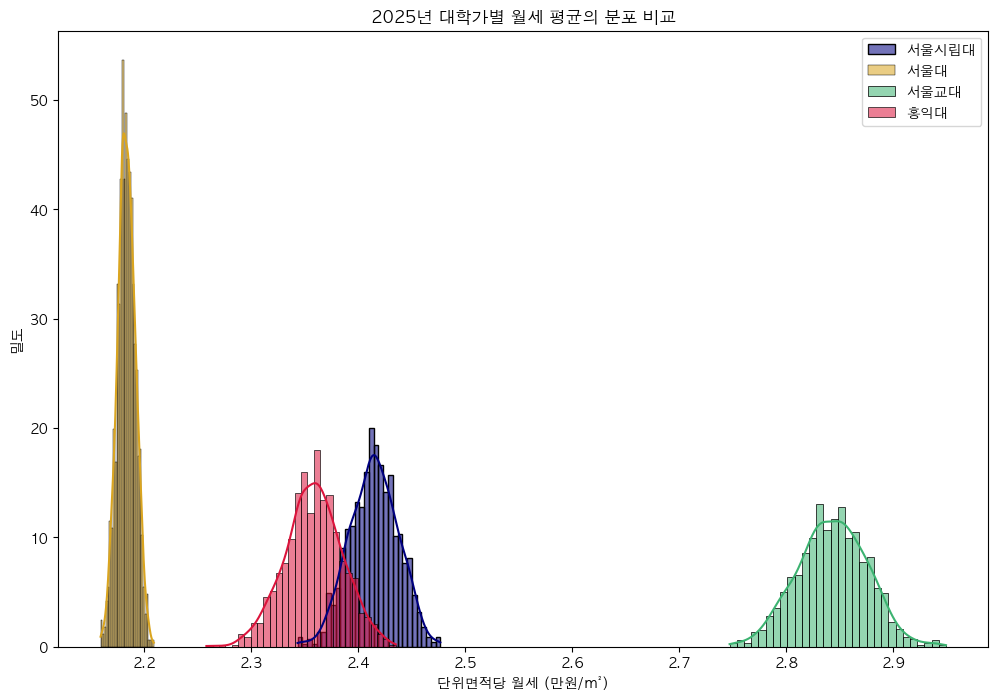

In [212]:
plt.figure(figsize=(12, 8))

for i, (univ, sample_means) in enumerate(results.items()):
    sns.histplot(sample_means, kde=True, color=colors[i], label=univ, bins=30, alpha=0.55, stat='density')
plt.legend()
plt.title('2025년 대학가별 월세 평균의 분포 비교')
plt.xlabel('단위면적당 월세 (만원/m²)')
plt.ylabel('밀도')
plt.show()


관측된 실제 평균 차이 (홍익대 - 서울시립대): -0.0571
순열 검정 p-value: 0.1550


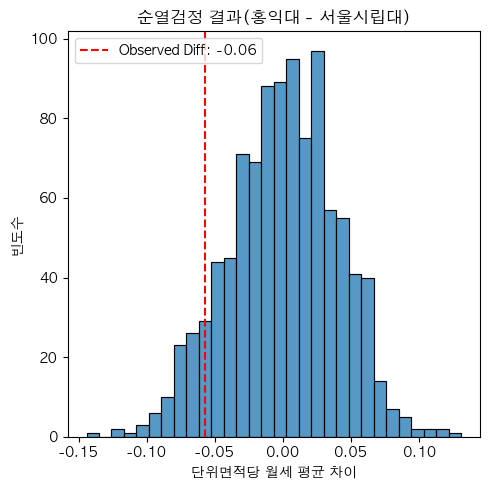

In [213]:
import random

random.seed(42)

target_df = pd.concat([df_uos['단위면적당_월세'], df_hongik['단위면적당_월세']], axis=0, ignore_index=True)
# 관측된 두 집단의 단위면적당 월세 평균 차이
obs_diff = df_hongik['단위면적당_월세'].mean() - df_uos['단위면적당_월세'].mean()

# 순열검정 통계량 생성 함수
def perm_func(x, nA, nB):
    n = nA + nB
    idx_B = set(random.sample(range(n), nB))
    idx_A = set(range(n)) - idx_B
    return x.loc[list(idx_B)].mean() - x.loc[list(idx_A)].mean()

perm_diffs = [perm_func(target_df, df_uos.shape[0], df_hongik.shape[0]) for _ in range(1000)]

perm_diffs = np.array(perm_diffs)
p_value = np.mean(np.abs(perm_diffs) >= np.abs(obs_diff))

print(f"관측된 실제 평균 차이 (홍익대 - 서울시립대): {obs_diff:.4f}")
print(f"순열 검정 p-value: {p_value:.4f}")

fig, axes = plt.subplots(figsize=(5, 5))
sns.histplot(perm_diffs, bins=30, ax=axes)
axes.set_xlabel('단위면적당 월세 평균 차이')
axes.set_ylabel('빈도수')
plt.title('순열검정 결과(홍익대 - 서울시립대)')

axes.axvline(obs_diff, color='red', linestyle='--', 
             label=f'Observed Diff: {obs_diff:.2f}')
axes.legend()

plt.tight_layout()
plt.show()


### 가설 4: 2024년과 2025년의 홍익대, 서울시립대 변화 비교
- 귀무가설: $(\mu_{홍익대, 2025} - \mu_{홍익대, 2024}) = (\mu_{시립대, 2025} - \mu_{시립대, 2024}), \Delta_{홍익대} = \Delta_{시립대}$
- 대립가설: $(\mu_{홍익대, 2025} - \mu_{홍익대, 2024}) > (\mu_{시립대, 2025} - \mu_{시립대, 2024}), \Delta_{홍익대} > \Delta_{시립대}$
- 이를 통해 확인하고자 하는 것은, *"홍익대 주변 건물 임대료가 전반적으로 올랐기 때문일 것이다."* 가설에 대한 검증이다.

In [214]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_2024_hs = pd.read_csv('Data/2024.csv', encoding='cp949')

# 피쳐 선택
selected_columns = ['접수년도', '자치구명', '법정동명', '전월세구분', '임대면적', '보증금(만원)', '임대료(만원)', '건물용도']
df_2024_hs = df_2024_hs[selected_columns].copy()

target_columns = ['임대면적', '보증금(만원)', '임대료(만원)']

# 결측치 제거 & 이상치 제거
df_2024_hs = df_2024_hs.dropna()

for i, col in enumerate(target_columns):
    df_2024_hs = df_2024_hs[df_2024_hs[col] > 0]

    q1 = df_2024_hs[col].quantile(0.25)
    q3 = df_2024_hs[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    df_2024_hs = df_2024_hs[(df_2024_hs[col] >= lower_bound) & (df_2024_hs[col] <= upper_bound)]

df_2024_hs = df_2024_hs.reset_index().copy()

# 단위면적당 월세
df_2024_hs['단위면적당_월세'] = df_2024_hs['임대료(만원)'] / df_2024_hs['임대면적']

# 계산 결과가 inf이거나 숫자가 아닌 경우는 분석에 방해가 되므로 제거
df_2024_hs = df_2024_hs.replace([np.inf, -np.inf], np.nan).dropna(subset=['단위면적당_월세'])

print("법정동명을 기준으로 '대학가' 변수 생성 및 데이터 필터링 중...")

# 1. 대학가 컬럼 생성
df_2024_hs['대학가'] = ''

# 2. 각 대학가에 해당하는 법정동 목록을 정의
univ_dong_map = {
    '서울시립대': ['전농동', '답십리동', '휘경동', '청량리동'],
    '서울교대': ['서초동'],
    '서울대': ['신림동', '봉천동'],
    '홍익대': ['상수동', '서교동', '합정동']
}

# 3. 각 대학가의 법정동에 해당하는 행에 '대학가' 이름을 부여
for univ_name, dong_list in univ_dong_map.items():
    mask = df_2024_hs['법정동명'].isin(dong_list)
    df_2024_hs.loc[mask, '대학가'] = univ_name

# 4. '대학가' 이름이 할당된 행들만 필터링하여 최종 분석용 데이터프레임 생성
df_univ = df_2024_hs[df_2024_hs['대학가'] != ''].reset_index().copy()

print("   - 생성 및 필터링 완료!")

# --- 최종 결과 확인 ---
print("\n--- 최종 분석용 데이터 정보 ---")
df_univ.info()


법정동명을 기준으로 '대학가' 변수 생성 및 데이터 필터링 중...
   - 생성 및 필터링 완료!

--- 최종 분석용 데이터 정보 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30302 entries, 0 to 30301
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   level_0   30302 non-null  int64  
 1   index     30302 non-null  int64  
 2   접수년도      30302 non-null  int64  
 3   자치구명      30302 non-null  object 
 4   법정동명      30302 non-null  object 
 5   전월세구분     30302 non-null  object 
 6   임대면적      30302 non-null  float64
 7   보증금(만원)   30302 non-null  int64  
 8   임대료(만원)   30302 non-null  int64  
 9   건물용도      30302 non-null  object 
 10  단위면적당_월세  30302 non-null  float64
 11  대학가       30302 non-null  object 
dtypes: float64(2), int64(5), object(5)
memory usage: 2.8+ MB


In [215]:
from scipy import stats
import pandas as pd
import numpy as np

# 검정 대상 데이터 2024년, 2025년
df_uos_2024 = df_univ[df_univ['대학가'] == '서울시립대']['단위면적당_월세']
df_hongik_2024 = df_univ[df_univ['대학가'] == '홍익대']['단위면적당_월세']
df_uos_2025 = df_uos['단위면적당_월세']
df_hongik_2025 = df_hongik['단위면적당_월세']

# 4개 그룹 평균, 표준오차 계산
mean_uos_2024, se_uos_2024 = df_uos_2024.mean(), df_uos_2024.sem()
mean_hongik_2024, se_hongik_2024 = df_hongik_2024.mean(), df_hongik_2024.sem()
mean_uos_2025, se_uos_2025 = df_uos_2025.mean(), df_uos_2025.sem()
mean_hongik_2025, se_hongik_2025 = df_hongik_2025.mean(), df_hongik_2025.sem()

# 검정 통계량 계산
delta_uos = mean_uos_2025 - mean_uos_2024
delta_hongik = mean_hongik_2025 - mean_hongik_2024
d = delta_hongik - delta_uos

# 검정 통계량 표준오차 계산
var_d = (se_hongik_2025**2) + (se_hongik_2024**2) + (se_uos_2025**2) + (se_uos_2024**2)
se_d = np.sqrt(var_d)

# T-통계량
T_stat = d / se_d

# p-value 계산
p_value = 1.0 - stats.norm.cdf(T_stat)

print("\n--- 상승폭 확인 ---")
print(f"서울시립대 평균 (2024년): {mean_uos_2024:.4f} (SE: {se_uos_2024:.4f})")
print(f"서울시립대 평균 (2025년): {mean_uos_2025:.4f} (SE: {se_uos_2025:.4f})")
print(f"  -> 서울시립대 상승폭 (Δ_UOS): {delta_uos:.4f}\n")

print(f"홍익대 평균 (2024년): {mean_hongik_2024:.4f} (SE: {se_hongik_2024:.4f})")
print(f"홍익대 평균 (2025년): {mean_hongik_2025:.4f} (SE: {se_hongik_2025:.4f})")
print(f"  -> 홍익대 상승폭 (Δ_HU): {delta_hongik:.4f}\n")

print("--- 검정 통계량 ---")
print(f"관찰된 차이의 차이 (D = Δ_HU - Δ_UOS): {d:.4f}")
print(f"D의 표준오차 (SE_D): {se_d:.4f}")
print(f"t (또는 z) 통계량: {T_stat:.4f}")
print(f"P-value (단측 검정: H_A: Δ_HU > Δ_UOS): {p_value:.4f}\n")

print("--- 결론 해석 ---")
if p_value < 0.05:
    print(f"p-value({p_value:.4f})가 0.05보다 작습니다.")
    print("결론: 홍익대의 2024년 대비 2025년 월세 상승폭은 서울시립대의 상승폭보다 통계적으로 유의미하게 '더 컸다'고 할 수 있습니다.")
    print("이것이 2025년에 두 그룹의 격차가 사라진 통계적인 이유입니다.")
else:
    print(f"p-value({p_value:.4f})가 0.05보다 큽니다.")
    print("결론: 홍익대의 월세 상승폭이 시각적으로는 커 보였으나, 통계적으로 유의미하게 '더 컸다'고 단정할 수 없습니다.")


--- 상승폭 확인 ---
서울시립대 평균 (2024년): 2.2799 (SE: 0.0213)
서울시립대 평균 (2025년): 2.4153 (SE: 0.0219)
  -> 서울시립대 상승폭 (Δ_UOS): 0.1354

홍익대 평균 (2024년): 2.1551 (SE: 0.0234)
홍익대 평균 (2025년): 2.3581 (SE: 0.0280)
  -> 홍익대 상승폭 (Δ_HU): 0.2030

--- 검정 통계량 ---
관찰된 차이의 차이 (D = Δ_HU - Δ_UOS): 0.0676
D의 표준오차 (SE_D): 0.0475
t (또는 z) 통계량: 1.4228
P-value (단측 검정: H_A: Δ_HU > Δ_UOS): 0.0774

--- 결론 해석 ---
p-value(0.0774)가 0.05보다 큽니다.
결론: 홍익대의 월세 상승폭이 시각적으로는 커 보였으나, 통계적으로 유의미하게 '더 컸다'고 단정할 수 없습니다.


### 가설 5. 2024년, 2025년 홍익대 건물용도 비율 변화 분석
- 귀무가설($H_{0}$): 접수연도(2024, 2025)는 건물용도와 서로 독립이다.
- 대립가설($H_{A}$): 접수연도(2024, 2025)는 건물용도와 서로 연관이 있다.
- 이를 통해, 홍익대 전체 임대료 증가가 아니라 고가 건물의 비율이 높아져 2024년에 비해 증가한 분포를 보이는 것인지 확인해보고자 한다.
- 결론: 대립가설 채택, **단독다가구 5.3%p 증가, 아파트 6.9%p 감소**


빈도 표
건물용도  단독다가구  아파트  연립다세대  오피스텔
2024    864  354   1024   272
2025    740  135    767   222

비율로 변환
건물용도  단독다가구    아파트  연립다세대   오피스텔
2024  34.37  14.08  40.73  10.82
2025  39.70   7.24  41.15  11.91

카이제곱 검정 결과
Chi-Squared Statistic: 54.2964
P-value: 0.0000
Degrees of Freedom: 3


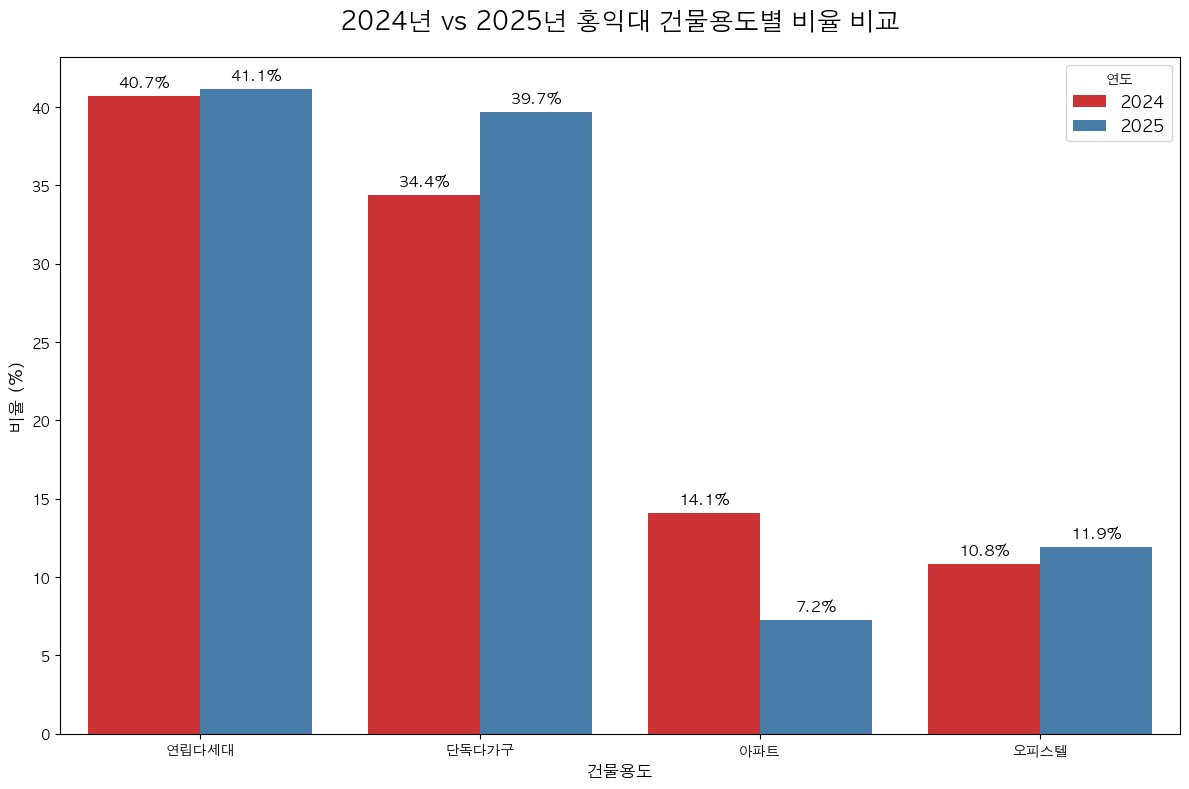

In [216]:
from scipy.stats import chi2_contingency
import pandas as pd
import matplotlib.pyplot as plt

# 검정 대상 데이터 2024년, 2025년 홍익대학교 건물용도
df_hongik_2024 = df_univ[df_univ['대학가'] == '홍익대']['건물용도']
df_hongik_2025 = df_hongik['건물용도']

counts_2024 = df_hongik_2024.value_counts()
counts_2025 = df_hongik_2025.value_counts()

contingency_table = pd.DataFrame({
    '2024': counts_2024,
    '2025': counts_2025
})

# 연도별 건물용도별 비율
# 2024년 비율 계산 (normalize=True 사용)
percents_2024 = df_hongik_2024.value_counts(normalize=True) * 100
df_perc_2024 = percents_2024.reset_index()
df_perc_2024.columns = ['건물용도', '비율']
df_perc_2024['연도'] = 2024 # '연도' 컬럼 추가

# 2025년 비율 계산 (normalize=True 사용)
percents_2025 = df_hongik_2025.value_counts(normalize=True) * 100
df_perc_2025 = percents_2025.reset_index()
df_perc_2025.columns = ['건물용도', '비율']
df_perc_2025['연도'] = 2025 # '연도' 컬럼 추가

# 검정 시작
# 빈도 표
contingency_table = contingency_table.transpose()
print(f'\n빈도 표')
print(contingency_table)

# 비율로 변환
contingency_table_prop = contingency_table.apply(
    lambda x: x/x.sum(),
    axis=1
)
print(f'\n비율로 변환')
print((contingency_table_prop * 100).round(2)) # 백분율로 출력

# 카이제곱 겁정
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("\n카이제곱 검정 결과")
print(f"Chi-Squared Statistic: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of Freedom: {dof}")

df_plot = pd.concat([df_perc_2024, df_perc_2025])
plt.figure(figsize=(12, 8)) # 캔버스 크기 조절
ax = sns.barplot(
    data=df_plot, 
    x='건물용도', 
    y='비율', 
    hue='연도', # '연도'별로 색상을 다르게 하여 그룹화
    palette='Set1' # 색상 팔레트
)

ax.set_title('2024년 vs 2025년 홍익대 건물용도별 비율 비교', fontsize=18, pad=20)
ax.set_xlabel('건물용도', fontsize=12)
ax.set_ylabel('비율 (%)', fontsize=12)
ax.legend(fontsize=12, title='연도', loc='upper right')

# 막대 위 수치 표시
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.1f}%', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points',
                    fontsize=11)

plt.tight_layout()
plt.show()


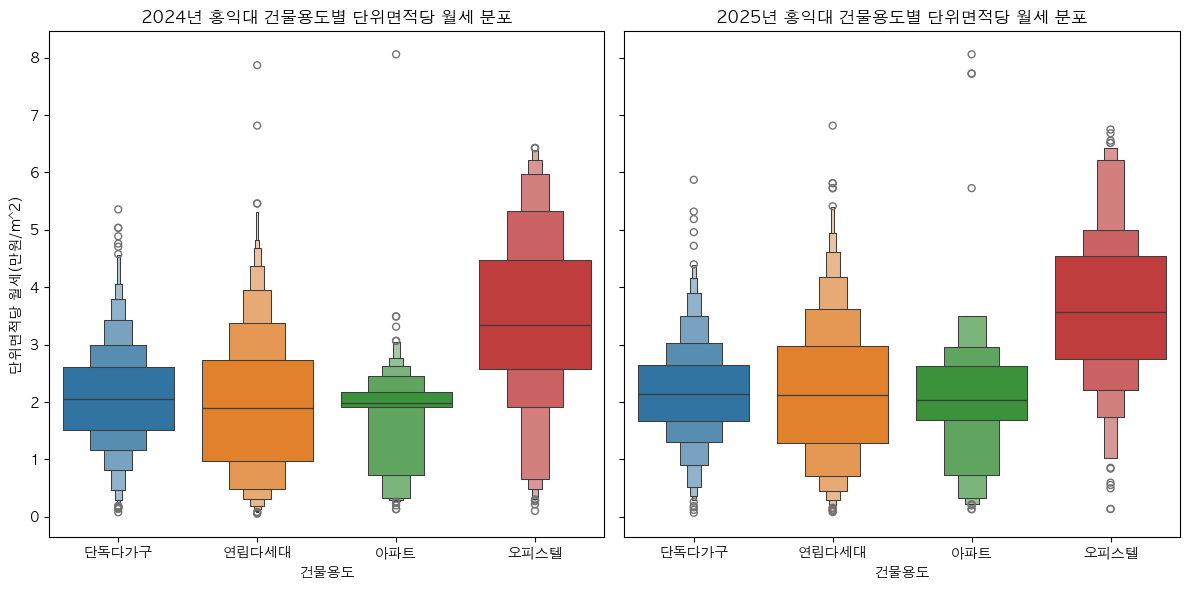

건물용도
아파트      1.910228
연립다세대    1.955908
단독다가구    2.080783
오피스텔     3.459660
Name: 단위면적당_월세, dtype: float64
건물용도
아파트      2.132811
단독다가구    2.174040
연립다세대    2.188281
오피스텔     3.695419
Name: 단위면적당_월세, dtype: float64


In [217]:
# 데이터프레임 준비
df_hongik_2024 = df_univ[df_univ['대학가'] == '홍익대']
df_hongik_2025 = df_hongik.copy()

# 건물용도별 단위면적당 월세 분포 시각화
fig, ax = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
sns.boxenplot(x='건물용도', y='단위면적당_월세', data=df_hongik_2024, hue='건물용도', ax=ax[0])
ax[0].set_title('2024년 홍익대 건물용도별 단위면적당 월세 분포')
ax[0].set_ylabel('단위면적당 월세(만원/m^2)')

sns.boxenplot(x='건물용도', y='단위면적당_월세', data=df_hongik_2025, hue='건물용도', ax=ax[1])
ax[1].set_title('2025년 홍익대 건물용도별 단위면적당 월세 분포')
ax[1].set_ylabel('단위면적당 월세(만원/m^2)')

plt.tight_layout()
plt.show()

# 건물용도별 단위면적당 월세 평균 산출
mean_2024 = df_hongik_2024.groupby('건물용도')['단위면적당_월세'].mean().sort_values()
mean_2025 = df_hongik_2025.groupby('건물용도')['단위면적당_월세'].mean().sort_values()

print(mean_2024)
print(mean_2025)

--- 2025년 홍익대 월세 평균 비교 ---
아파트 평균: 2.13
단독다가구 평균: 2.17


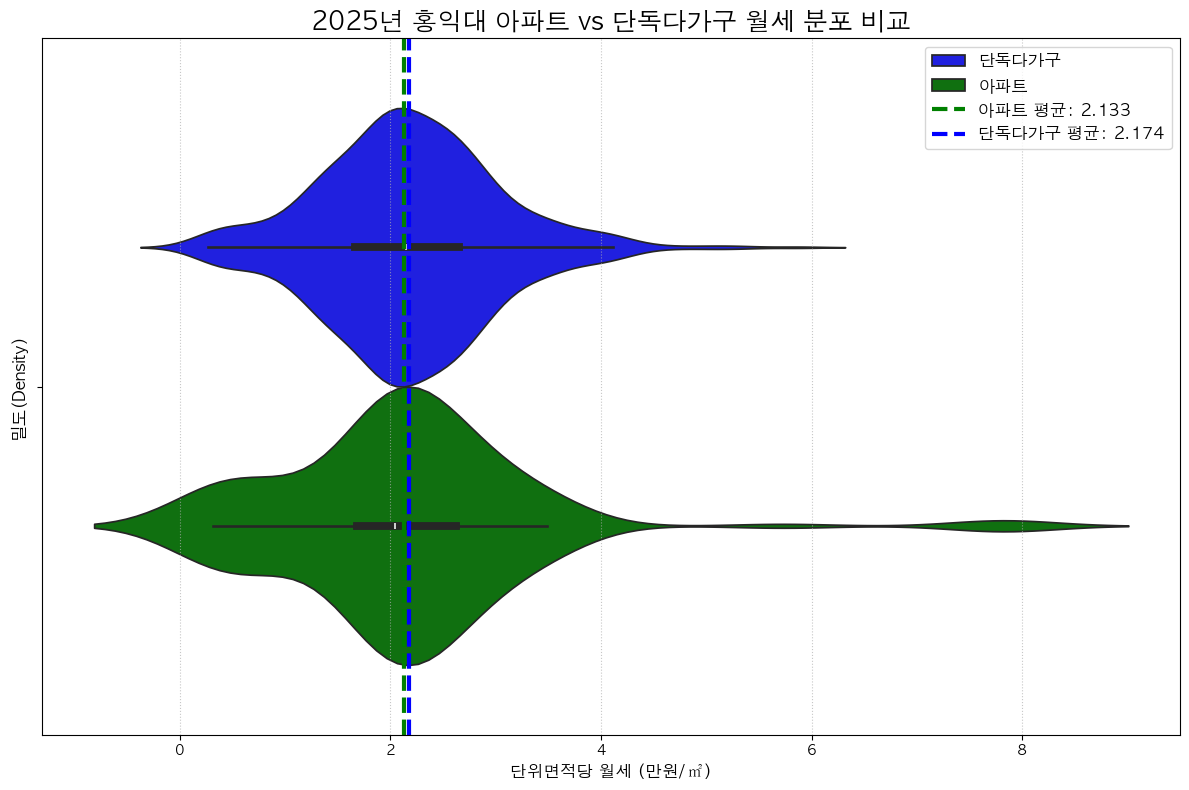

In [218]:
target_df = pd.DataFrame(df_hongik_2025[df_hongik_2025['건물용도'].isin(['아파트', '단독다가구'])])

apt_mean = target_df[target_df['건물용도'] == '아파트']['단위면적당_월세'].mean()
dandok_mean = target_df[target_df['건물용도'] == '단독다가구']['단위면적당_월세'].mean()

print(f"--- 2025년 홍익대 월세 평균 비교 ---")
print(f"아파트 평균: {apt_mean:.2f}")
print(f"단독다가구 평균: {dandok_mean:.2f}")

fig, ax = plt.subplots(figsize=(12, 8))

sns.violinplot(
    data=target_df,
    x='단위면적당_월세',
    hue='건물용도',
    ax=ax,
    palette={'아파트': 'green', '단독다가구': 'blue'}
)

ax.axvline(apt_mean, color='green', linestyle='--', linewidth=3, label=f'아파트 평균: {apt_mean:.3f}')
ax.axvline(dandok_mean, color='blue', linestyle='--', linewidth=3, label=f'단독다가구 평균: {dandok_mean:.3f}')

ax.set_title('2025년 홍익대 아파트 vs 단독다가구 월세 분포 비교', fontsize=18)
ax.set_xlabel('단위면적당 월세 (만원/㎡)', fontsize=12)
ax.set_ylabel('밀도(Density)', fontsize=12)
ax.legend(fontsize=12)
ax.grid(axis='x', linestyle=':', alpha=0.7)
fig.tight_layout()
plt.show()

### 가설 6: 2024년과 2025년의 서울시립대 월세 평균 비교
- 귀무가설($H_{0}$): $\mu_{2024, 시립대} = \mu_{2025, 시립대}$
- 대립가설($H_{A}$): $\mu_{2024, 시립대} \neq \mu_{2025, 시립대}$

2024년 거래량 수: 4640
2025년 거래량 수: 4567


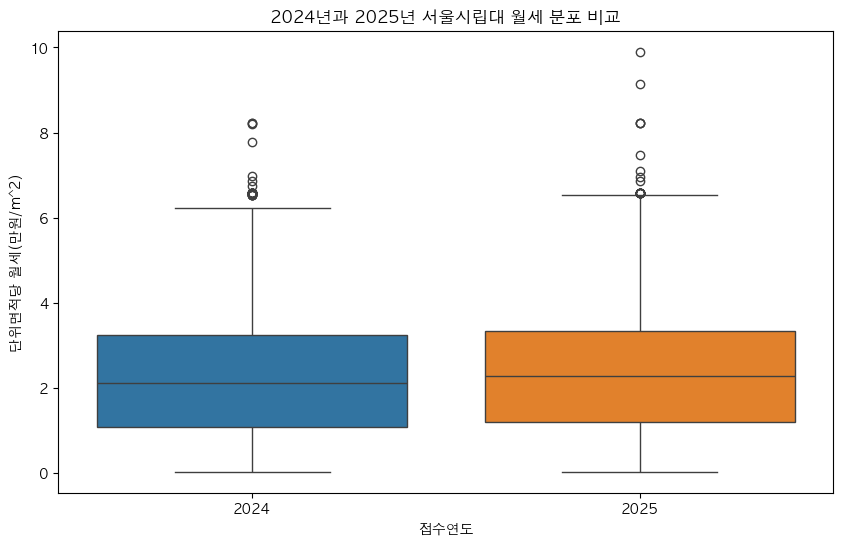

In [219]:
df_uos_2024 = df_univ[df_univ['대학가'] == '서울시립대'].copy()
df_uos_2025 = df_uos.copy()

df_uos_2024['접수연도'] = '2024'
df_uos_2025['접수연도'] = '2025'

# 데이터 수 확인
print(f'2024년 거래량 수: {df_uos_2024.shape[0]}')
print(f'2025년 거래량 수: {df_uos_2025.shape[0]}')

target_df = pd.concat([df_uos_2024[['접수연도', '단위면적당_월세']], df_uos_2025[['접수연도', '단위면적당_월세']]])

# 시각화
plt.figure(figsize=(10, 6))
sns.boxplot(data=target_df, x='접수연도', y='단위면적당_월세', hue='접수연도')
plt.title('2024년과 2025년 서울시립대 월세 분포 비교')
plt.xlabel('접수연도')
plt.ylabel('단위면적당 월세(만원/m^2)')
plt.show()

In [220]:
# 독립 표본 t검정, 두 그룹의 분산이 다르다고 해봤음
t_stat, p_value = stats.ttest_ind(df_uos_2024['단위면적당_월세'], df_uos_2025['단위면적당_월세'], equal_var=False)

print("\n--- 독립 표본 T검정 결과---")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

print('둘의 차이는 유의미하다고 할 수 있다. (귀무가설 기각)')


--- 독립 표본 T검정 결과---
T-statistic: -4.4341
P-value: 0.0000
둘의 차이는 유의미하다고 할 수 있다. (귀무가설 기각)


### **가설 7 : 기숙사가 임대료에 음(-)의 영향을 미칠 것이다**
가설 검증을 하기 위해 따라서, 추가 대학교의 대학가 변수를 생성하기 위해 동 표본을 더욱 확보하였다
또한, 통제변수로 자치구별, 비대학가의 평균 월세 변수를 계산하였다.

In [255]:
print("법정동명을 기준으로 '대학가' 변수 생성 및 데이터 필터링 중...")

df2 = df.copy()

# 1. '대학가'라는 새로운 컬럼을 생성
df2['대학가'] = ''
df2['비대학가'] =''
# 2. 각 대학가에 해당하는 법정동 목록을 정의

univ_dong_map = {
    '서울시립대': ['전농동', '휘경동', '이문동'],
    '건국대': ['화양동', '자양동', '구의동'],
    '서울대': ['신림동', '봉천동', '대학동'],
    '중앙대': ['흑석동', '상도동', '노량진동'],
    '숙명여대': ['청파동', '원효로1동', '원효로2동', '효창동'],
    '동국대': ['필동', '장충동', '신당동', '광희동'],
    '홍익대': ['동교동', '서교동', '연남동', '망원동', '창천동'],
    '상명대': ['평창동', '홍지동', '홍제동', '부암동'],
    '국민대': ['정릉동', '길음동', '돈암동'],
    '고려대': ['안암동', '제기동', '종암동', '용두동'],
    '이화여대': ['대현동', '신촌동', '노고산동', '염리동']
}

non_univ_dong_map = {
    '고려대': ['장안동','석관동'],
    '서울시립대': ['장안동', '용답동'],
    '건국대': ['중곡동', '능동'],
    '서울대': ['남현동', '인헌동'],
    '중앙대': ['사당동', '대방동'],
    '숙명여대': ['후암동', '이촌동'],
    '동국대': ['약수동', '신당동'],
    '홍익대': ['성산동', '공덕동'],
    '이화여대': ['남가좌동', '북가좌동'],
    '상명대': ['가회동', '삼청동'],
    '국민대': [ '하월곡동']
}
# 3. 각 대학가의 법정동에 해당하는 행에 '대학가' 이름을 부여
for univ_name, dong_list in univ_dong_map.items():
    mask = df2['법정동명'].isin(dong_list)
    df2.loc[mask, '대학가'] = univ_name
# 3.1 각 대학가의 법정동에 해당하는 행에 '비대학가' 이름을 부여
for univ_name, dong_list in non_univ_dong_map.items():
    mask = df2['법정동명'].isin(dong_list)
    df2.loc[mask, '비대학가'] = univ_name
# 4. '대학가' 컬럼이 비어있지 않은 행만 선택하여 새로운 데이터프레임 생성
df_analysis = df2[df2['대학가'] != ''].copy()
df_non_univ = df2[df2['비대학가'] != ''].copy()
print("   - 생성 및 필터링 완료!")

# --- 최종 결과 확인 ---
print("\n--- 최종 분석용 데이터 정보 ---")
df_analysis.info()

print("\n--- 각 대학가별 데이터 개수 ---")
print(df_analysis['대학가'].value_counts())

print("\n--- 최종 데이터 샘플 (상위 5개) ---")
# '법정동명'이 '대학가'에 잘 매칭되었는지 확인
print(df_analysis[['자치구명', '법정동명', '대학가', '단위면적당_월세']].head())

print("\n--- non_univ  ---")
df_non_univ.info()
print(df_non_univ[['자치구명', '법정동명', '비대학가', '단위면적당_월세']].head())

법정동명을 기준으로 '대학가' 변수 생성 및 데이터 필터링 중...
   - 생성 및 필터링 완료!

--- 최종 분석용 데이터 정보 ---
<class 'pandas.core.frame.DataFrame'>
Index: 267578 entries, 25 to 3557750
Data columns (total 12 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   접수년도      267578 non-null  int64  
 1   자치구명      267578 non-null  object 
 2   법정동명      267578 non-null  object 
 3   전월세구분     267578 non-null  object 
 4   임대면적      267578 non-null  float64
 5   보증금(만원)   267578 non-null  int64  
 6   임대료(만원)   267578 non-null  int64  
 7   건물용도      267578 non-null  object 
 8   건축년도      267578 non-null  float64
 9   단위면적당_월세  267578 non-null  float64
 10  대학가       267578 non-null  object 
 11  비대학가      267578 non-null  object 
dtypes: float64(3), int64(3), object(6)
memory usage: 26.5+ MB

--- 각 대학가별 데이터 개수 ---
대학가
서울대      105253
건국대       43035
중앙대       27186
홍익대       25441
서울시립대     20226
고려대       13044
국민대       11067
이화여대       8072
동국대        7936
상명대        5282
숙명여

In [256]:
print(df_analysis[['자치구명', '법정동명', '대학가', '단위면적당_월세']].head(20))

    자치구명  법정동명   대학가  단위면적당_월세
25   마포구  노고산동  이화여대  0.315657
30   마포구  노고산동  이화여대  0.239464
31   마포구  노고산동  이화여대  0.287356
32   마포구  노고산동  이화여대  1.900585
33   마포구  노고산동  이화여대  2.387914
34   마포구  노고산동  이화여대  2.436647
173  관악구   신림동   서울대  2.217295
177  관악구   신림동   서울대  0.240674
178  관악구   신림동   서울대  0.060168
179  관악구   신림동   서울대  0.060168
180  관악구   신림동   서울대  0.058377
182  관악구   신림동   서울대  1.395089
183  관악구   신림동   서울대  2.070870
185  관악구   신림동   서울대  0.268528
189  관악구   신림동   서울대  0.741107
190  관악구   신림동   서울대  0.988142
191  관악구   신림동   서울대  2.034884
192  관악구   신림동   서울대  0.896414
193  관악구   신림동   서울대  1.804368
194  관악구   신림동   서울대  0.552209


In [257]:
#대학가 평균 건축 연도 
df_analysis[['자치구명', '법정동명','건축년도', '대학가', '단위면적당_월세']].head(20)
average_build_year = df_analysis.groupby('대학가')['건축년도'].mean().reset_index()
average_build_year.columns = ['대학가', '평균_건축년도']
print("### 대학가별 평균 건축 연도 ###")
print(average_build_year)


### 대학가별 평균 건축 연도 ###
      대학가      평균_건축년도
0     건국대  2000.749832
1     고려대  2003.622738
2     국민대  2004.598446
3     동국대  2001.197959
4     상명대  2002.862173
5     서울대  2005.000209
6   서울시립대  2002.749728
7    숙명여대  2002.669884
8    이화여대  2010.384539
9     중앙대  2003.249871
10    홍익대  2001.904446


In [258]:
average_pay_year = df_analysis.groupby('대학가')['단위면적당_월세'].mean().reset_index()
average_pay_year.columns = ['대학가', '평균_단위월세']
print("### 대학가별 평균 단위월세 ###")
print(average_pay_year)


### 대학가별 평균 단위월세 ###
      대학가   평균_단위월세
0     건국대  1.900716
1     고려대  1.855662
2     국민대  1.332480
3     동국대  1.869659
4     상명대  1.164659
5     서울대  1.773646
6   서울시립대  1.850456
7    숙명여대  1.552217
8    이화여대  2.784846
9     중앙대  1.834544
10    홍익대  1.992585


In [259]:
average_non_univ = df_non_univ.groupby('비대학가')['단위면적당_월세'].mean().reset_index()
#average_non_univ.columns = ['비대학가', '평균_단위월세']
average_non_univ.columns = ['대학가', '비대학가 평균_단위월세']#INNER JOIN 하려고 열 이름을 같게 만듬
print("### 비 대학가별 평균 단위월세 ###")
print(average_non_univ)


### 비 대학가별 평균 단위월세 ###
      대학가  비대학가 평균_단위월세
0     건국대      1.453999
1     고려대      1.115451
2     국민대      1.564472
3     동국대      1.869659
4     상명대      1.279444
5     서울대      1.907787
6   서울시립대      1.683116
7    숙명여대      1.367989
8    이화여대      1.411110
9     중앙대      1.677705
10    홍익대      2.167804


In [260]:
df_final = pd.merge(average_pay_year, average_non_univ,
                    on='대학가', how='left')  # inner 말고 left


#log(단위 면적당 임대료) = b0, b1(기숙사비), b2(수용률), b3(구 비대학가 임대료), 
#b4(평균 건축연도), b5(log 재학생 수), b6(학교에서 평균 지하철역 거리) + e
#해석 b계수*100%로 해석 예) 0.0005 -> 0.5%영향 

In [261]:
#(단위 면적당 임대료
# 1. 'df_stats'와 'df_agg' 병합
# '대학가' 컬럼이 두 데이터프레임 모두에 존재하며 값이 일치해야 합니다.

df_stats = pd.read_csv('E:/Users/SIN/Downloads/재학생수,수용률,기숙사비.csv', encoding='cp949')
# df_analysis 데이터프레임이 로드되어 있다고 가정

# 1. 대학가별 평균 임대료와 평균 건축년도 계산
df_agg = df_analysis.groupby('대학가').agg(
    평균_단위면적당_월세=('단위면적당_월세', 'mean'),
    평균_건축년도=('건축년도', 'mean')
).reset_index()

# 2. Log(단위 면적당 월세) 변수 생성 (종속 변수)
import numpy as np
df_agg['Log_월세'] = np.log(df_agg['평균_단위면적당_월세']) 

# 3. 불필요한 원본 컬럼 제거
df_agg.drop(columns=['평균_단위면적당_월세'], inplace=True)

FileNotFoundError: [Errno 2] No such file or directory: 'E:/Users/SIN/Downloads/재학생수,수용률,기숙사비.csv'

In [ ]:
df_final = pd.merge(df_stats, df_agg, on='대학가', how='inner')
df_final = pd.merge(average_non_univ, df_final, on = '대학가', how='inner')

NameError: name 'df_stats' is not defined

회귀모형으로 가설 검증

In [ ]:
# 'Log_월세'가 종속 변수 Y로 정의되었다고 가정
# 1. 독립 변수 (X) 목록 재정의
independent_vars = [
    '기숙사비 (2인실 월 환산액, 만 원)', 
    '수용률 (%)', 
    '비대학가 평균_단위월세', 
    '평균_건축년도', 
    'Log(재학생수)', 
    '지하철역 도보 시간 (분)'
]
# 2. 데이터 정제
# 'Log_월세'와 독립 변수들만 남기고 NaN 행을 제거합니다.
columns_to_keep = ['Log_월세'] + independent_vars
df_reg = df_final[columns_to_keep].dropna() 
print(f"결측값 제거 후 {len(df_reg)}개 대학 데이터로 분석을 진행합니다.")

# 3. 종속 변수 (Y) 및 독립 변수 (X) 정의
Y = df_reg['Log_월세']

# 독립 변수 X에 컬럼 리스트 자체가 아닌, 해당 컬럼들의 데이터를 담은 DataFrame을 할당합니다.
X = df_reg[independent_vars] 

# 4. 모든 X 컬럼이 숫자형인지 최종 확인 
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# NaN이 다시 생겼을 경우를 대비해 다시 dropna (11개 데이터이므로 필수)
X = X.dropna()
Y = Y[X.index] # X에서 제거된 행에 맞춰 Y의 인덱스도 조정합니다.


# 5. 상수항 (절편, b0) 추가
X = sm.add_constant(X)

# 6. OLS(최소자승법) 모델 적합 및 실행
model = sm.OLS(Y, X)
results = model.fit()

# 7. 회귀 분석 결과 요약 출력
print("\n### OLS 회귀 분석 결과 ###")
print(results.summary())

KeyError: "['Log_월세', '기숙사비 (2인실 월 환산액, 만 원)', '수용률 (%)', '평균_건축년도', 'Log(재학생수)', '지하철역 도보 시간 (분)'] not in index"

p값이 낮은 변수를 제거하며 가설검증 1

In [ ]:
# 'Log_월세'가 종속 변수 Y로 정의되었다고 가정
# 1. 독립 변수 (X) 목록 재정의
independent_vars = [
    '기숙사비 (2인실 월 환산액, 만 원)', 
    '수용률 (%)', 
    '비대학가 평균_단위월세', 
    #'평균_건축년도', 
    #'Log(재학생수)', 
    '지하철역 도보 시간 (분)'
]
# 2. 데이터 정제
# 'Log_월세'와 독립 변수들만 남기고 NaN 행을 제거합니다.
columns_to_keep = ['Log_월세'] + independent_vars
df_reg = df_final[columns_to_keep].dropna() 
print(f"결측값 제거 후 {len(df_reg)}개 대학 데이터로 분석을 진행합니다.")

# 3. 종속 변수 (Y) 및 독립 변수 (X) 정의
Y = df_reg['Log_월세']

# 독립 변수 X에 컬럼 리스트 자체가 아닌, 해당 컬럼들의 데이터를 담은 DataFrame을 할당합니다.
X = df_reg[independent_vars] 

# 4. 모든 X 컬럼이 숫자형인지 최종 확인 
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# NaN이 다시 생겼을 경우를 대비해 다시 dropna (11개 데이터이므로 필수)
X = X.dropna()
Y = Y[X.index] # X에서 제거된 행에 맞춰 Y의 인덱스도 조정합니다.


# 5. 상수항 (절편, b0) 추가
X = sm.add_constant(X)

# 6. OLS(최소자승법) 모델 적합 및 실행
model = sm.OLS(Y, X)
results = model.fit()

# 7. 회귀 분석 결과 요약 출력
print("\n### OLS 회귀 분석 결과 ###")
print(results.summary())

p값이 낮은 변수를 제거며 가설검증 2

In [ ]:
# 'Log_월세'가 종속 변수 Y로 정의되었다고 가정
# 1. 독립 변수 (X) 목록 재정의
independent_vars = [
    '기숙사비 (2인실 월 환산액, 만 원)', 
    '수용률 (%)', 
    '비대학가 평균_단위월세', 
    #'평균_건축년도', 
    #'Log(재학생수)', 
    #'지하철역 도보 시간 (분)'
]
# 2. 데이터 정제
# 'Log_월세'와 독립 변수들만 남기고 NaN 행을 제거합니다.
columns_to_keep = ['Log_월세'] + independent_vars
df_reg = df_final[columns_to_keep].dropna() 
print(f"결측값 제거 후 {len(df_reg)}개 대학 데이터로 분석을 진행합니다.")

# 3. 종속 변수 (Y) 및 독립 변수 (X) 정의
Y = df_reg['Log_월세']

# 독립 변수 X에 컬럼 리스트 자체가 아닌, 해당 컬럼들의 데이터를 담은 DataFrame을 할당합니다.
X = df_reg[independent_vars] 

# 4. 모든 X 컬럼이 숫자형인지 최종 확인 
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# NaN이 다시 생겼을 경우를 대비해 다시 dropna (11개 데이터이므로 필수)
X = X.dropna()
Y = Y[X.index] # X에서 제거된 행에 맞춰 Y의 인덱스도 조정합니다.


# 5. 상수항 (절편, b0) 추가
X = sm.add_constant(X)

# 6. OLS(최소자승법) 모델 적합 및 실행
model = sm.OLS(Y, X)
results = model.fit()

# 7. 회귀 분석 결과 요약 출력
print("\n### OLS 회귀 분석 결과 ###")
print(results.summary())

결론 가설 기각.

추가로, 부스트랩 기반 표준 오차 계산

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# 원래 회귀모델에서 X, Y는 이미 정의되어 있음
n = len(Y)
B = 1000  # 부트스트랩 반복 횟수
coefs = []

for _ in range(B):
    sample_idx = np.random.choice(n, n, replace=True)  # 복원추출
    X_boot = X.iloc[sample_idx]
    Y_boot = Y.iloc[sample_idx]
    model_boot = sm.OLS(Y_boot, X_boot).fit()
    coefs.append(model_boot.params)

boot_df = pd.DataFrame(coefs)
boot_se = boot_df.std()  # 부트스트랩 표준오차
boot_ci = boot_df.quantile([0.025, 0.975])  # 95% 신뢰구간
print("부트스트랩 표준오차:\n", boot_se)
print("부트스트랩 95% 신뢰구간:\n", boot_ci)


Ridge / Lasso 회귀로 다중공선성 완화

In [ ]:
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler

# X, Y 정규화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.drop(columns=['const'], errors='ignore'))  # 상수항 제외
Y_array = Y.values

# Ridge 회귀 (교차검증 기반)
ridge_model = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5).fit(X_scaled, Y_array)
ridge_coef = ridge_model.coef_
print("\nRidge 회귀 결과:")
print(pd.Series(ridge_coef, index=X.columns.drop('const', errors='ignore')))
print("선택된 alpha:", ridge_model.alpha_)

# Lasso 회귀 (교차검증 기반)
lasso_model = LassoCV(alphas=np.logspace(-3, 3, 50), cv=5, max_iter=10000).fit(X_scaled, Y_array)
lasso_coef = lasso_model.coef_
print("\nLasso 회귀 결과:")
print(pd.Series(lasso_coef, index=X.columns.drop('const', errors='ignore')))
print("선택된 alpha:", lasso_model.alpha_)


In [ ]:
from sklearn.linear_model import RidgeCV
ridge_cv = RidgeCV(alphas=np.logspace(-2, 3, 50), cv=3).fit(X_scaled, Y_array)
print(ridge_cv.alpha_)


In [ ]:
from sklearn.linear_model import lasso_path
alphas, coefs, _ = lasso_path(X_scaled, Y_array)
plt.plot(-np.log10(alphas), coefs.T)
plt.xlabel("-log10(alpha)")
plt.ylabel("Coefficients")
plt.title("Lasso 경로 그래프")


Ridge 회귀에서는 주요 변수의 부호가 OLS와 동일하게 유지되어,
수용률 및 비대학가 평균 단위월세의 양(+)의 영향이 구조적으로 안정적임을 확인하였다.
반면, Lasso 회귀에서는 표본 수 제한과 높은 정규화 강도(α=1000)로 인해 모든 변수가 제거되어,
변수 선택보다는 모형 안정화 중심의 Ridge 접근이 적절함을 확인하였다.

# Machine Learning

In [252]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
import numpy as np

# 1. 분석 대상 데이터 준비
# 모델링에 사용할 변수 선정 (더 추가 가능)
features = ['접수년도', '임대면적', '보증금(만원)', '대학가', '건물용도']
target = '단위면적당_월세'

data_model = df_analysis[features + [target]].copy()

# 2. 범주형 변수는 One-Hot Encoding (대학가, 건물용도)
data_model = pd.get_dummies(data_model, columns=['대학가', '건물용도'], drop_first=True)

# 3. Train/Test Split (시계열 특성 고려)
# 2024년 데이터를 Test set으로, 그 이전(2018~2023)을 Train set으로 설정
train_data = data_model[data_model['접수년도'] < 2024]
test_data = data_model[data_model['접수년도'] == 2024]

X_train = train_data.drop(target, axis=1)
y_train = train_data[target]

X_test = test_data.drop(target, axis=1)
y_test = test_data[target]

print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")

Training samples: 226008, Test samples: 41570


In [253]:
# 4. GradientBoostingRegressor로 학습

"""
What is GradientBoostingRegressor?
    - decision tree 기반의 앙상블 학습 기법.
    - 여러 개의 약한 학습기(주로 결정 트리)를 순차적으로 학습시켜 강력한 예측 모델을 만듦.
    - 각 트리는 이전 트리의 오차를 보완하는 방식으로 학습됨.

why GradientBoostingRegressor?
    0. 시계열 데이터에 강함: 시계열 특성을 반영한 학습 가능.
    1. 강력한 예측 성능: 여러 약한 학습기를 결합하여 복잡한 패턴을 학습.
    2. 과적합 방지: 학습률과 트리 깊이 조절로 과적합 위험 감소.
    3. 다양한 손실 함수 지원: 회귀, 분류 등 다양한 문제에 적용 가능.
    4. 변수 중요도 제공: 예측에 기여하는 변수 파악 가능.
"""

## n_estimators: 트리의 개수, learning_rate: 학습률, max_depth: 트리의 깊이
model = GradientBoostingRegressor(n_estimators=500, learning_rate=0.05, max_depth=5, random_state=42)
model.fit(X_train, y_train)

# 5. 2024년 데이터로 성능 평가
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Model Performance (2024년 데이터 기준):")
print(f"RMSE: {rmse:.4f} (단위: 만원/㎡)")
print(f"R^2 Score: {r2:.4f}")

Model Performance (2024년 데이터 기준):
RMSE: 0.6490 (단위: 만원/㎡)
R^2 Score: 0.7359


ValueError: The palette dictionary is missing keys: {'동국대', '건국대', '상명대', '고려대', '이화여대', '국민대', '숙명여대', '중앙대'}

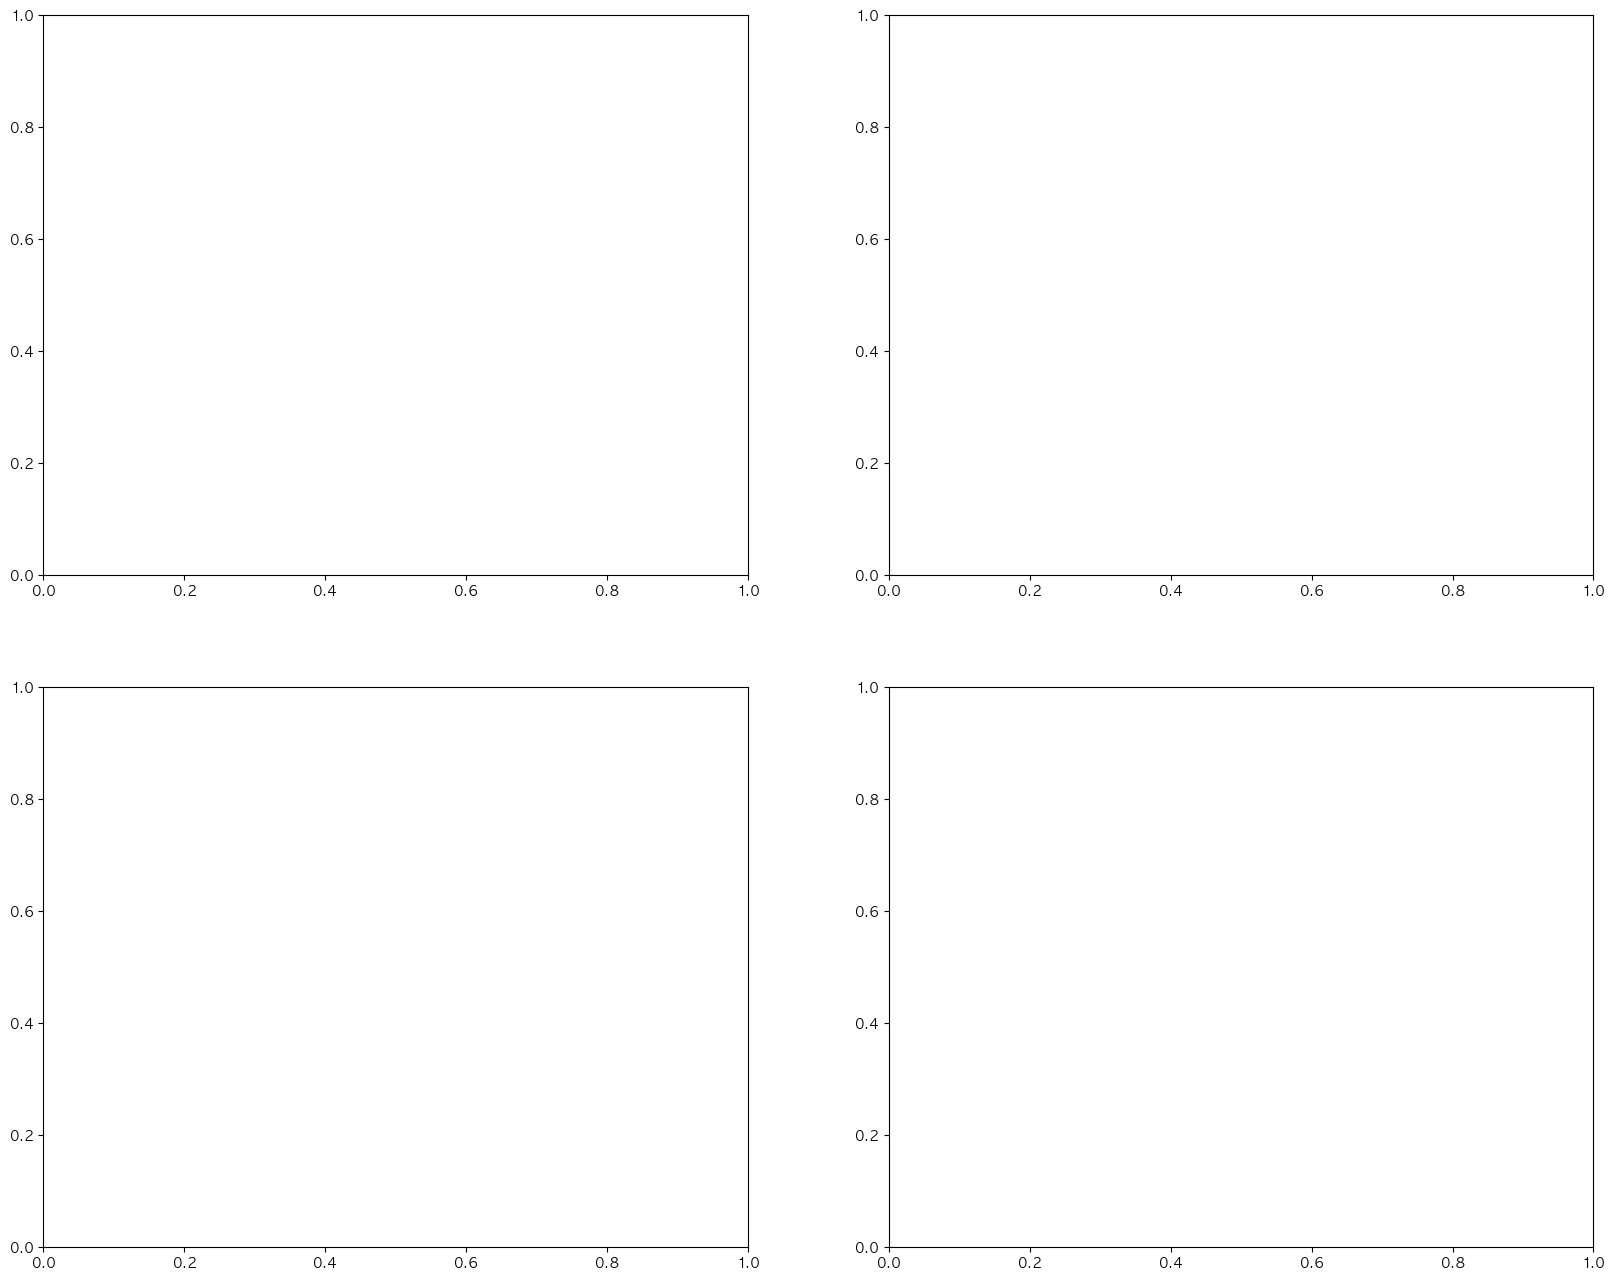

In [254]:

# ---------------------------------------------------------
# 1. 대학별 지정 색상 매핑
# ---------------------------------------------------------
# 서울대(노랑), 서울교대(초록), 서울시립대(파랑), 홍익대(빨강)
univ_palette = {
    '서울대': '#E8D284',
    '서울교대': '#2ECC71',
    '서울시립대': '#436BBA',
    '홍익대': '#FF6B6B'
}

# ---------------------------------------------------------
# 2. 데이터 준비
# ---------------------------------------------------------
comparison_df = test_data.copy()
comparison_df['실제값'] = y_test
comparison_df['예측값'] = y_pred
comparison_df['오차'] = comparison_df['실제값'] - comparison_df['예측값']
comparison_df['오차율(%)'] = (comparison_df['오차'] / comparison_df['실제값']) * 100
comparison_df['대학가'] = df_analysis.loc[comparison_df.index, '대학가']

# ---------------------------------------------------------
# 3. 시각화 (지정된 색상 적용)
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# (1) 실제값 vs 예측값 산점도 (대학별 색상 적용)
# hue='대학가'를 통해 점마다 해당 대학의 색깔을 입힙니다.
sns.scatterplot(
    x='실제값', y='예측값', 
    data=comparison_df, 
    hue='대학가', 
    palette=univ_palette,  # ★ 지정된 색상 적용
    alpha=0.6, 
    s=60,
    ax=axes[0, 0]
)
# 기준선 (y=x)
min_val = min(comparison_df['실제값'].min(), comparison_df['예측값'].min())
max_val = max(comparison_df['실제값'].max(), comparison_df['예측값'].max())
axes[0, 0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Fit')
axes[0, 0].set_title('2024년 실제 vs 예측 가격 (대학별 색상)', fontsize=16)
axes[0, 0].set_xlabel('실제 가격 (만원/㎡)')
axes[0, 0].set_ylabel('예측 가격 (만원/㎡)')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend(loc='upper left')

# (2) 오차(Residual) 분포 (대학별 KDE Plot)
# 대학별로 오차 분포가 어떻게 다른지 선 그래프(밀도함수)로 보여줍니다.
sns.kdeplot(
    data=comparison_df, 
    x='오차', 
    hue='대학가', 
    palette=univ_palette,  # ★ 지정된 색상 적용
    fill=True, 
    alpha=0.2, 
    ax=axes[0, 1]
)
axes[0, 1].axvline(x=0, color='black', linestyle='--', lw=1)
axes[0, 1].set_title('대학별 예측 오차 분포', fontsize=16)
axes[0, 1].set_xlabel('오차 (실제값 - 예측값)')
axes[0, 1].set_ylabel('밀도')
axes[0, 1].grid(True, alpha=0.3)

# (3) 2024년 예측 결과와 실제 비교 (막대 그래프)
mean_actual = comparison_df.groupby('대학가')['실제값'].mean()
mean_pred = comparison_df.groupby('대학가')['예측값'].mean()
bar_width = 0.35
indices = np.arange(len(mean_actual))
bars1 = axes[1, 0].bar(indices, mean_actual[univ_palette.keys()], bar_width, label='실제값', color=[univ_palette[univ] for univ in univ_palette.keys()], alpha=1.0)
bars2 = axes[1, 0].bar(indices + bar_width, mean_pred[  univ_palette.keys()], bar_width, label='예측값', color=[univ_palette[univ] for univ in univ_palette.keys()], alpha=0.7)
axes[1, 0].set_xticks(indices + bar_width / 2)
axes[1, 0].set_xticklabels(univ_palette.keys())
axes[1, 0].set_title('2024년 대학가별 실제값 vs 예측값 비교', fontsize=16)
axes[1, 0].set_ylabel('평균 단위면적당 월세 (만원/㎡)')
axes[1, 0].legend()
axes[1, 0].grid(True, axis='y', alpha=0.3)

# (4) 대학가별 오차율 Boxplot
# 오차율이 너무 큰 이상치 제외 (-100 ~ 100% 사이)
filtered_df = comparison_df[comparison_df['오차율(%)'].between(-100, 100)]

sns.boxplot(
    x='대학가', 
    y='오차율(%)', 
    data=filtered_df, 
    palette=univ_palette, # ★ 지정된 색상 적용
    ax=axes[1, 1],
    order=list(univ_palette.keys()) # 순서 고정
)
axes[1, 1].axhline(y=0, color='red', linestyle='--', lw=2)
axes[1, 1].set_title('대학가별 예측 오차율 분포', fontsize=16)
axes[1, 1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


--- 2025년 대학가별 단위면적당 월세 예측 결과 ---
     대학가  2025_예측_단위면적당_월세
0    서울대          1.727495
1  서울시립대          0.883445
2   서울교대          1.229103
3    홍익대          1.033119


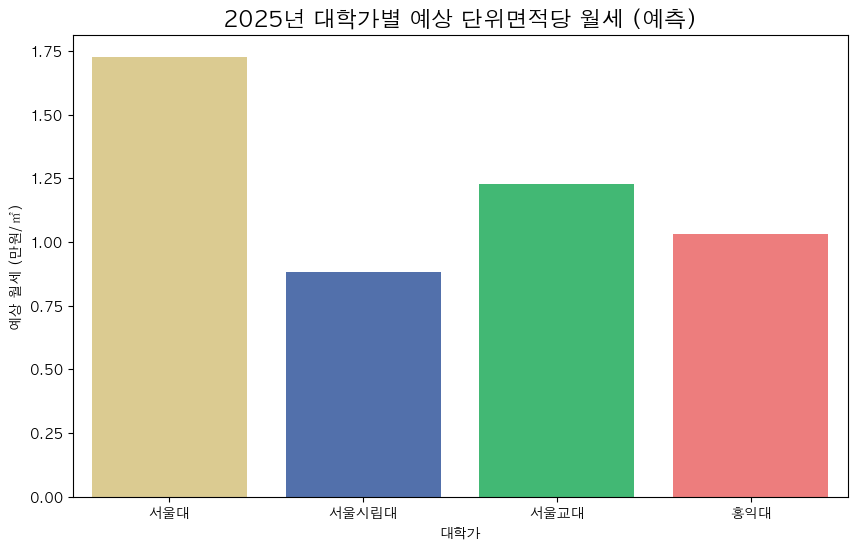

In [ ]:
# 6. 2025년 예측을 위한 가상의 입력 데이터 생성 (2025년 데이터가 안불러와짐)

universities = ['서울대', '서울시립대', '서울교대', '홍익대']
future_predictions = []

univ_palette = {
    '서울대': '#E8D284',
    '서울교대': '#2ECC71',
    '서울시립대': '#436BBA',
    '홍익대': '#FF6B6B'
}

# 각 대학가별로 대표적인 샘플 데이터를 생성 (평균값 활용)
for univ in universities:
    # 해당 대학가의 평균 면적 및 보증금 계산
    univ_mean_area = df_analysis[df_analysis['대학가'] == univ]['임대면적'].mean()
    univ_mean_deposit = df_analysis[df_analysis['대학가'] == univ]['보증금(만원)'].mean()
    
    # 입력 데이터프레임 생성 (One-Hot Encoding 컬럼 포함)
    input_row = pd.DataFrame(0, index=[0], columns=X_train.columns)
    input_row['접수년도'] = 2025
    input_row['임대면적'] = univ_mean_area
    input_row['보증금(만원)'] = univ_mean_deposit
    
    # 해당 대학가 및 건물용도(예: 아파트나 원룸 등 대표값) 더미 변수 설정
    # 컬럼명이 '대학가_서울대' 와 같은 형식인지 확인 필요
    if f'대학가_{univ}' in input_row.columns:
        input_row[f'대학가_{univ}'] = 1
    
    # 예측 수행
    pred_price = model.predict(input_row)[0]
    future_predictions.append({'대학가': univ, '2025_예측_단위면적당_월세': pred_price})

# 결과 출력
df_future = pd.DataFrame(future_predictions)
print("\n--- 2025년 대학가별 단위면적당 월세 예측 결과 ---")
print(df_future)

# 시각화
plt.figure(figsize=(10, 6))
sns.barplot(x='대학가', y='2025_예측_단위면적당_월세', data=df_future, palette=univ_palette)
plt.title('2025년 대학가별 예상 단위면적당 월세 (예측)', fontsize=16)
plt.ylabel('예상 월세 (만원/㎡)')
plt.show()

#### 대학가별 법정동별 20대 주민등록인구 데이터 추가

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
import numpy as np
import pandas as pd
import glob
import os

# 데이터 파일이 저장된 폴더 경로
path = './Data'

# CSV 파일 검색
all_file_list = glob.glob(os.path.join(path, '20*.csv'))
exclude_file_list = ['./Data/2025.csv', './Data/2025_hs.csv']
file_list = [f for f in all_file_list if f not in exclude_file_list]

print(f"찾은 CSV 파일 개수: {len(file_list)}")
print(f"파일 목록: {file_list}")

all_data_frames = []

for file in file_list:
    try:
        df_single_year = pd.read_csv(file, encoding='utf-8', low_memory=False)
        all_data_frames.append(df_single_year)
    except UnicodeDecodeError:
        try:
            df_single_year = pd.read_csv(file, encoding='cp949', low_memory=False)
            all_data_frames.append(df_single_year)
        except Exception as e:
            print(f"  [실패] '{os.path.basename(file)}' 파일은 두 인코딩 모두 실패: {e}")

# 파일이 성공적으로 하나라도 읽혔다면 데이터 통합을 진행
if all_data_frames:
    df_combined = pd.concat(all_data_frames, ignore_index=True)
    print(f"\n통합된 데이터프레임 크기: {df_combined.shape}")
    
else:
    print("\n통합할 데이터가 없습니다. 파일 경로 또는 파일 내용을 확인해주세요.")

# 임대면적 전처리
df = df_combined.copy()
selected_columns = ['접수년도', '자치구명', '법정동명', '전월세구분', '임대면적', '보증금(만원)', '임대료(만원)', '건물용도']
df = df[selected_columns]
df = df.dropna()
df = df[df['임대면적'] > 0]
q1 = df['임대면적'].quantile(0.25)
q3 = df['임대면적'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr ; upper_bound = q3 + 1.5 * iqr
df = df[(df['임대면적'] >= lower_bound) & (df['임대면적'] <= upper_bound)]

# 임대료 전처리
df = df[df['임대료(만원)'] > 0]

# 이상치 제거
q1 = df['임대료(만원)'].quantile(0.25)
q3 = df['임대료(만원)'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr ; upper_bound = q3 + 1.5 * iqr

df = df[(df['임대료(만원)'] >= lower_bound) & (df['임대료(만원)'] <= upper_bound)]

df = df[df['보증금(만원)'] > 0]

# 이상치 제거
q1 = df['보증금(만원)'].quantile(0.25)
q3 = df['보증금(만원)'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr ; upper_bound = q3 + 1.5 * iqr
df = df[(df['보증금(만원)'] >= lower_bound) & (df['보증금(만원)'] <= upper_bound)]

# 단위면적당 월세 계산
df['단위면적당_월세'] = df['임대료(만원)'] / df['임대면적']

# 무한대 및 NaN 값 제거
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['단위면적당_월세'])

df['대학가'] = ''

# 2. 각 대학가에 해당하는 법정동 목록을 정의
univ_dong_map = {
    '서울시립대': ['전농동', '답십리동', '휘경동', '청량리동'],
    '서울교대': ['서초동'],
    '서울대': ['신림동', '봉천동'],
    '홍익대': ['상수동', '서교동', '합정동']
}

# 3. 각 대학가의 법정동에 해당하는 행에 '대학가' 이름을 부여
for univ_name, dong_list in univ_dong_map.items():
    mask = df['법정동명'].isin(dong_list)
    df.loc[mask, '대학가'] = univ_name

# 4. '대학가' 컬럼이 비어있지 않은 행만 선택하여 새로운 데이터프레임 생성
df_analysis = df[df['대학가'] != ''].copy()

df_final = pd.read_csv('Data/Seoul_20s_pop_univ_mapped.csv')
df_final['접수년도'] = df_final['접수년도'].apply(float)
df_final = df_final.groupby(['접수년도', '대학가', '법정동명'])['20대 인구 합계'].sum().reset_index()

# 1. 분석 대상 데이터 준비
# 모델링에 사용할 변수 선정 (더 추가 가능)
features = ['접수년도', '임대면적', '보증금(만원)', '대학가', '건물용도', '법정동명']
target = '단위면적당_월세'

data_model = df_analysis[features + [target]].copy()

data_model = pd.merge(data_model, df_final, on=['접수년도', '대학가', '법정동명'], how='left')
data_model['20대 인구 합계'] = data_model['20대 인구 합계'].fillna(0)

print(f'최종 데이터 개수: {len(data_model)}')

univ_info = data_model['대학가']


# 2. 범주형 변수는 One-Hot Encoding (대학가, 건물용도)
data_model = pd.get_dummies(data_model, columns=['대학가', '건물용도', '법정동명'], drop_first=True)
print(data_model.head())    

# 3. Train/Test Split (시계열 특성 고려)
# 2024년 데이터를 Test set으로, 그 이전(2018~2023)을 Train set으로 설정
train_data = data_model[data_model['접수년도'] < 2024]
test_data = data_model[data_model['접수년도'] == 2024]

X_train = train_data.drop(target, axis=1)
y_train = train_data[target]

X_test = test_data.drop(target, axis=1)
y_test = test_data[target]

print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")

## n_estimators: 트리의 개수, learning_rate: 학습률, max_depth: 트리의 깊이
model = GradientBoostingRegressor(n_estimators=500, learning_rate=0.05, max_depth=5, random_state=42)
model.fit(X_train, y_train)

# 5. 2024년 데이터로 성능 평가
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Model Performance (2024년 데이터 기준):")
print(f"RMSE: {rmse:.4f} (단위: 만원/㎡)")
print(f"R^2 Score: {r2:.4f}")

찾은 CSV 파일 개수: 7
파일 목록: ['./Data/2020.csv', './Data/2021.csv', './Data/2023.csv', './Data/2022.csv', './Data/2019.csv', './Data/2018.csv', './Data/2024.csv']

통합된 데이터프레임 크기: (3557756, 23)
최종 데이터 개수: 162752
   접수년도   임대면적  보증금(만원)  단위면적당_월세  20대 인구 합계  대학가_서울대  대학가_서울시립대  대학가_홍익대  \
0  2020  18.04     1000  2.217295      54698     True      False    False   
1  2020  16.62     8000  0.240674      54698     True      False    False   
2  2020  16.62     7980  0.060168      54698     True      False    False   
3  2020  16.62     8000  0.060168      54698     True      False    False   
4  2020  17.13     8200  0.058377      54698     True      False    False   

   건물용도_아파트  건물용도_연립다세대  건물용도_오피스텔  법정동명_봉천동  법정동명_상수동  법정동명_서교동  법정동명_서초동  \
0     False       False       True     False     False     False     False   
1     False       False       True     False     False     False     False   
2     False       False       True     False     False     False     False   
3     False       Fa

## 전월세 데이터와 서울시_건축물대장_총괄표제부 불러오기 & 병합

In [ ]:
import pandas as pd

# 1. 원본 데이터프레임 로드 (경로를 가정)
house_df = pd.read_csv("E:/Users/SIN/Downloads/서울특별시_전월세가_2024/서울특별시_전월세가_2024.csv", sep=',', encoding='cp949')

# 2. 필터링 및 독립적인 복사본 생성 (.copy() 사용)
# can_house_df는 이제 house_df와 완전히 분리된 독립적인 데이터프레임임
can_house_df = house_df[house_df['지번구분코드'] == 1].copy()

'''# 3. 데이터 전처리: NaN을 0으로 채우고 정수 변환 (IntCastingNaNError 방지)
can_house_df['본번'] = can_house_df['본번'].fillna(0).astype(int)
can_house_df['부번'] = can_house_df['부번'].fillna(0).astype(int)'''

# 4. '건물위치' 열 초기 생성 (부번이 0인 경우 포함)
can_house_df['건물위치'] ='서울특별시 '+ can_house_df['자치구명'] +' '+ can_house_df['법정동명'] +' '+ can_house_df['본번'].astype(int).astype(str)

# 5. 조건에 맞는 행만 선택하여 수정 (.loc와 마스킹 사용)
# '부번'이 0이 아닌 행만 선택하는 마스크 생성
mask = can_house_df['부번'] != 0

# 마스크를 사용하여 해당 행의 '건물위치' 열만 벡터화 방식으로 업데이트
can_house_df.loc[mask, '건물위치'] = (
    can_house_df.loc[mask, '건물위치'] + '-' + can_house_df.loc[mask, '부번'].astype(int).astype(str)
)

print(can_house_df.head())

3. 공급데이터의 '대지위치'정보와 전월세정보의 '건물위치'정보를 바탕으로 필터링
24년도의 경우, 전체 522001개, 지번구분 ==1 (주소 존재 행 개수 값) 398469개 중 193482개 남음

병합 데이터 결과

In [ ]:
tmp_df = pd.read_csv("E:/Users/SIN/Downloads/Merged_Results/merged_data_2018.csv", sep=',', encoding='cp949',low_memory=False)
tmp_df

In [ ]:
tmp_df['에너지효율등급값'].value_counts()

In [ ]:
tmp_df.columns

In [ ]:
tmp_df['총주차수'].value_counts()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import platform

'''# OS에 따른 폰트 설정
if platform.system() == 'Darwin': # Mac 환경
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows': # Windows 환경
    plt.rc('font', family='Malgun Gothic')'''

plt.rc('font', family='Malgun Gothic')
# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 0값이 너무 많으므로 로그 스케일을 적용하면 데이터 분포를 더 잘 볼 수 있습니다.
plt.figure(figsize=(10, 6))
plt.hist(tmp_df['총주차수'], bins=50, log=True, color='skyblue', edgecolor='black')

plt.title('총주차수 히스토그램')
plt.xlabel('총주차수')
plt.ylabel('빈도 (Log Scale)')
plt.grid(True, axis='y', alpha=0.5)
plt.show()

In [ ]:
all_col=[#'접수년도', '자치구코드', '자치구명', '법정동코드', '법정동명', '지번구분코드',
       #'지번구분', '본번', '부번', 
       '층', 
       #'계약일', '전월세구분', '임대면적', '보증금(만원)', '임대료(만원)',
       #'건물명', '건축년도', '건물용도',
        # '계약기간', '신규계약구분', '갱신청구권사용', '종전보증금', '종전임대료',
       #'건물위치', '대지위치', '시군구코드명', '법정동코드명', '대지구분코드명', '주지번', '부지번', '특수지명',
       '블록번호', '로트번호', 
       #'새주소도로코드명', '새주소법정동코드명', '새주소지상지하구분코드명', '새주소주지번',
       #'새주소부지번', '건축물대장일련번호', '대장구분코드명', '대장종류코드명', '대지면적', '건축면적', '건폐율',
       #'연면적', '용적률산정연면적', '용적률', '주용도코드', '주용도코드명', '기타용도내용', 
       '세대수', '가구수',
       '호수', 
       #'승용승강기수', '비상용승강기수', '주건축물수', '부속건축물수', '부속건축물면적', '총주차수',
       #'옥내기계식대수', '옥내기계식면적', '옥외기계식대수', '옥외기계식면적', '옥내자주식대수', '옥내자주식면적',
       #'옥외자주식대수', '옥외자주식면적', '허가일자', '착공일자', '사용승인일자', '에너지효율등급값', '에너지절감률',
       #'EPI점수', '친환경건축물등급값', '친환경건축물인증점수', '지능형건축물등급값', '지능형건축물인증점수', 
       '대학가']

In [ ]:
import pandas as pd
import glob
import os

# 데이터 파일이 저장된 폴더 경로
path = 'E:/Users/SIN/Downloads/Merged_Results/'

# CSV 파일 검색
file_list = glob.glob(os.path.join(path, '*.csv'))

print(f"찾은 CSV 파일 개수: {len(file_list)}")
print(f"파일 목록: {file_list}")

all_data_frames = []

for file in file_list:
    try:
        df_single_year = pd.read_csv(file, encoding='utf-8', low_memory=False)
        all_data_frames.append(df_single_year)
    except UnicodeDecodeError:
        try:
            df_single_year = pd.read_csv(file, encoding='cp949', low_memory=False)
            all_data_frames.append(df_single_year)
        except Exception as e:
            print(f"  [실패] '{os.path.basename(file)}' 파일은 두 인코딩 모두 실패: {e}")

# 파일이 성공적으로 하나라도 읽혔다면 데이터 통합을 진행
if all_data_frames:
    df_combined = pd.concat(all_data_frames, ignore_index=True)
    print(f"\n통합된 데이터프레임 크기: {df_combined.shape}")
    
else:
    print("\n통합할 데이터가 없습니다. 파일 경로 또는 파일 내용을 확인해주세요.")

df = df_combined.copy()

In [ ]:
import numpy as np
# 단위면적당 월세 계산
df['단위면적당_월세'] = df['임대료(만원)'] / df['임대면적']

# 무한대 및 NaN 값 제거
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['단위면적당_월세'])

print("'단위면적당_월세' 컬럼 생성 완료!")
print(df[['임대면적', '임대료(만원)', '단위면적당_월세']].head())

# 건물연령 컬럼 생성
# 낡은 건물 vs 신축은 월세가 크게 다르기 때문에 건물연령을 계산하여 새로운 컬럼으로 추가

df['건물연령'] = df['접수년도'] - df['건축년도']
df['건물연령'] = df['건물연령'].clip(lower=0)  # 혹시 이상한 값 방지

# 임대료 시즌성 반영을 위해 계약일에서 월/분기 정보 추출

df = df.reset_index(drop=True)

df['계약일'] = pd.to_datetime(
    df['계약일'].astype(str),   # 문자열로 바꾸고
    format='%Y%m%d',            # "YYYYMMDD" 형식이라고 알려주기
    errors='coerce'             # 이상한 값은 NaT로
)

df['계약월'] = df['계약일'].dt.month
df['계약분기'] = df['계약일'].dt.quarter

df[['계약일', '계약월', '계약분기']]

# 계약기간
# 예: '24개월', '12개월' 이런 식이라고 가정
df['계약기간_월'] = (
    df['계약기간']
    .str.extract(r'(\d+)')
    .astype(float)
)

df[['계약기간', '계약기간_월']]



In [ ]:
import seaborn as sns
# 음수 및 임대료가 없는 경우 제거
df = df[df['임대료(만원)'] > 0]

# 이상치 제거
q1 = df['임대료(만원)'].quantile(0.25)
q3 = df['임대료(만원)'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr ; upper_bound = q3 + 1.5 * iqr

df = df[(df['임대료(만원)'] >= lower_bound) & (df['임대료(만원)'] <= upper_bound)]

plt.figure(figsize=(6, 3))
sns.boxenplot(x=df['임대료(만원)'])
plt.title('임대료 분포 (이상치 제거 후)')
plt.show()

In [ ]:
# 음수 보증금 제거
df = df[df['보증금(만원)'] > 0]


# 이상치 제거
q1 = df['보증금(만원)'].quantile(0.25)
q3 = df['보증금(만원)'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr ; upper_bound = q3 + 1.5 * iqr
df = df[(df['보증금(만원)'] >= lower_bound) & (df['보증금(만원)'] <= upper_bound)]

plt.figure(figsize=(6, 3))
sns.boxenplot(x=df['보증금(만원)'])
plt.title('보증금 분포 (이상치 제거 후)')
plt.show()

In [ ]:
# 건물연령 컬럼 생성
# 낡은 건물 vs 신축은 월세가 크게 다르기 때문에 건물연령을 계산하여 새로운 컬럼으로 추가

df['건물연령'] = df['접수년도'] - df['건축년도']
df['건물연령'] = df['건물연령'].clip(lower=0)  # 혹시 이상한 값 방지

In [ ]:
# 임대료 시즌성 반영을 위해 계약일에서 월/분기 정보 추출

df = df.reset_index(drop=True)

df['계약일'] = pd.to_datetime(
    df['계약일'].astype(str),   # 문자열로 바꾸고
    format='%Y%m%d',            # "YYYYMMDD" 형식이라고 알려주기
    errors='coerce'             # 이상한 값은 NaT로
)

df['계약월'] = df['계약일'].dt.month
df['계약분기'] = df['계약일'].dt.quarter

df[['계약일', '계약월', '계약분기']]

In [ ]:
# 계약기간
# 예: '24개월', '12개월' 이런 식이라고 가정
df['계약기간_월'] = (
    df['계약기간']
    .str.extract(r'(\d+)')
    .astype(float)
)

df[['계약기간', '계약기간_월']]

In [ ]:
print("법정동명을 기준으로 '대학가' 변수 생성 및 데이터 필터링 중...")

# 1. '대학가'라는 새로운 컬럼을 생성
df['대학가'] = ''

# 2. 각 대학가에 해당하는 법정동 목록을 정의
univ_dong_map = {
    '서울시립대': ['전농동', '답십리동', '휘경동', '청량리동'],
    '서울교대': ['서초동'],
    '서울대': ['신림동', '봉천동'],
    '홍익대': ['상수동', '서교동', '합정동']
}

# 3. 각 대학가의 법정동에 해당하는 행에 '대학가' 이름을 부여
for univ_name, dong_list in univ_dong_map.items():
    mask = df['법정동명'].isin(dong_list)
    df.loc[mask, '대학가'] = univ_name

# 4. '대학가' 컬럼이 비어있지 않은 행만 선택하여 새로운 데이터프레임 생성
df_analysis = df[df['대학가'] != ''].copy()

print("   - 생성 및 필터링 완료!")

# --- 최종 결과 확인 ---
print("\n--- 최종 분석용 데이터 정보 ---")
df_analysis.info()

print("\n--- 각 대학가별 데이터 개수 ---")
print(df_analysis['대학가'].value_counts())

print("\n--- 최종 데이터 샘플 (상위 5개) ---")
# '법정동명'이 '대학가'에 잘 매칭되었는지 확인
print(df_analysis[['자치구명', '법정동명', '대학가', '단위면적당_월세']].head())

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. 분석 대상 데이터 준비
# =========================
target = '단위면적당_월세'

# (1) 수치형 피처 + 범주형 피처 분리
num_features = [
    '접수년도', '임대면적', '보증금(만원)', '건물연령',
    #'계약월', '계약분기', '계약기간_월', '층'
]
cat_features = [
    '대학가', '건물용도', '전월세구분', '자치구명'
]

features = num_features + cat_features
data_model = df_analysis[features + [target]].copy()

# 결측치 제거
data_model = data_model.dropna(subset=[target])

# =========================
# 2. 범주형 변수 One-Hot Encoding
# =========================
# 선형 회귀와 XGB 모두 원핫 인코딩된 데이터를 사용해도 무방합니다.
data_model = pd.get_dummies(
    data_model,
    columns=cat_features,
    drop_first=True
)

# =========================
# 3. Train/Test Split (연도 기준)
# =========================
train_data = data_model[data_model['접수년도'] < 2024]
test_data  = data_model[data_model['접수년도'] == 2024]

X_train = train_data.drop(columns=[target])
y_train = train_data[target]
X_test  = test_data.drop(columns=[target])
y_test  = test_data[target]

print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")

# =========================
# 4. 타깃 로그 변환 (분포가 한쪽으로 치우쳐 있을 때 유리)
# =========================
y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)
from sklearn.impute import SimpleImputer # 이 줄을 맨 위 import 쪽에 추가하거나 여기에 써도 됩니다.

# =========================
# 5. 결측치 처리(Imputation) 및 스케일링 (StandardScaler)
# =========================
# Ridge(선형모델)를 쓰려면 결측치가 하나도 없어야 합니다.

# 1. 결측치 채우기 (평균값으로 대치)
imputer = SimpleImputer(strategy='mean')

# Train 데이터로 '학습'하고 채우기
X_train_filled = imputer.fit_transform(X_train)
# Test 데이터는 Train의 평균값으로 채우기 (Data Leakage 방지)
X_test_filled = imputer.transform(X_test)

# 2. 스케일링
scaler = StandardScaler()

# 채워진 데이터(X_train_filled)로 스케일링 수행
X_train_scaled = scaler.fit_transform(X_train_filled)
X_test_scaled = scaler.transform(X_test_filled)

# (옵션) 데이터프레임으로 다시 변환 (컬럼명 확인 등을 위해 필요할 때만)
# X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
# X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# =========================
# 6. 모델 1: XGBoost (기존 GB 대체) - 하이퍼파라미터 튜닝
# =========================
# XGBoost는 스케일링된 데이터를 써도 되고 안 써도 되지만, 관리 편의상 scaled 데이터를 씁니다.

tscv = TimeSeriesSplit(n_splits=4)

xgb_param_dist = {
    "n_estimators": [200, 400, 800],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0], # XGBoost 전용 파라미터 (피처 샘플링)
}

xgb_base = XGBRegressor(random_state=42, n_jobs=-1) # n_jobs=-1로 병렬 처리

search = RandomizedSearchCV(
    xgb_base,
    param_distributions=xgb_param_dist,
    n_iter=20, # 시간 절약을 위해 횟수 조정 (필요시 늘리세요)
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("XGBoost 튜닝 시작...")
search.fit(X_train_scaled, y_train_log)
best_xgb_model = search.best_estimator_
print("Best XGB params:", search.best_params_)

# =========================
# 7. 모델 2: Linear Regression (Ridge)
# =========================
# 단순 LinearRegression보다 과적합 방지가 되는 Ridge를 추천합니다.
linear_model = Ridge(alpha=1.0) 
linear_model.fit(X_train_scaled, y_train_log)


# =========================
# 8. 블렌딩 (Blending) 및 최종 평가
# =========================

# (1) 각 모델 예측 (로그 상태)
pred_log_xgb = best_xgb_model.predict(X_test_scaled)
pred_log_linear = linear_model.predict(X_test_scaled)

# (2) 최적 가중치 찾기 (0.0 ~ 1.0) - 단순 Loop로 최적 비율 탐색
best_rmse = float('inf')
best_weight = 0.5
best_final_pred = None

# 실험할 비율 범위 (XGB 비중을 0.0부터 1.0까지 0.1단위로 테스트)
for weight in np.arange(0.0, 1.1, 0.1):
    # 가중 합산 (로그 상태에서 블렌딩)
    blended_log = (weight * pred_log_xgb) + ((1 - weight) * pred_log_linear)
    
    # 로그 역변환 (원래 가격으로 복구)
    pred_real = np.expm1(blended_log)
    
    # 평가
    current_rmse = mean_squared_error(y_test, pred_real) ** 0.5
    
    if current_rmse < best_rmse:
        best_rmse = current_rmse
        best_weight = weight
        best_final_pred = pred_real



In [ ]:
print(f"\n[결과] 최적 블렌딩 비율 -> XGB: {best_weight:.1f}, Linear: {1-best_weight:.1f}")
print(f"Final Test RMSE: {best_rmse:.3f}")

# R2 Score 계산
r2 = r2_score(y_test, best_final_pred)
print(f"Final Test R²  : {r2:.3f}")

# =========================
# 9. 피처 중요도 (XGBoost 기준)
# =========================
importances = best_xgb_model.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = X_train.columns # 혹은 one-hot encoding된 컬럼명 리스트

top_n = min(20, len(features)) # 상위 20개
plt.rc('font', family='Malgun Gothic')
# 마이너스 기호가 깨지는 현상 해결
plt.rc('axes', unicode_minus=False)

plt.figure(figsize=(10, 6))
plt.title(f"XGBoost Feature Importances (Top {top_n})")
plt.barh(range(top_n), importances[indices][:top_n], align="center")
# 스케일링 후 numpy array로 변하면 컬럼명이 없을 수 있으니 원본 X_train 컬럼명 사용
plt.yticks(range(top_n), [feature_names[i] for i in indices[:top_n]])
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# 블렌딩 코드 바로
print(f"XGBoost 단독 RMSE: {mean_squared_error(y_test, np.expm1(pred_log_xgb))**0.5:.4f}")
print(f"Linear 단독 RMSE: {mean_squared_error(y_test, np.expm1(pred_log_linear))**0.5:.4f}")